# Heart Attack Risk Prediction — End-to-End Machine Learning Project

**A comprehensive, industry-grade classification pipeline combining EDA, advanced statistics,
feature engineering, multi-tier model benchmarking, hyperparameter tuning, explainability
(SHAP & LIME), and bias-variance / overfitting diagnostics.**

This notebook consolidates and extends two reference notebooks (`heart-attack-risk-79-beats.ipynb`
and `heart-attack-risk-prediction.ipynb`) into a single reproducible workflow.

### Table of Contents
1. Environment Setup & GPU Activation (Colab)
2. Data Loading & Initial Audit
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Advanced & Granular Statistical Analysis
6. Feature Engineering
7. Train/Test Split & Leak-Free Preprocessing Pipeline
8. Baseline Models
9. Advanced Models
10. Hyperparameter Tuning — Top 3 Models
11. Model Comparison — All Levels
12. Granular Feature Importance
13. Explainability — SHAP
14. Explainability — LIME
15. Bias-Variance Trade-off & Overfitting Diagnostics
16. Final Model Selection, Artifact Export & Download

> ⚠️ **Disclaimer**: The dataset is *synthetic* and for educational/ML-practice purposes only.
> It must not be used for real medical diagnosis or clinical decision-making.

## 1. Environment Setup & GPU Activation (Colab)

This phase installs/imports all dependencies, fixes random seeds for reproducibility, sets
global plotting styles, and detects whether a Colab GPU runtime is active. If a GPU is found,
`XGBoost` is configured to use it (`device='cuda'`); otherwise it silently falls back to CPU.

**To enable GPU in Colab:** `Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4)`,
then `Runtime -> Restart session` before running all cells.

In [1]:
# --- Package installation (safe no-op if already present; Colab-friendly) -------------
import importlib, subprocess, sys

REQUIRED = ["xgboost", "lightgbm", "shap", "lime", "statsmodels"]
missing = [p for p in REQUIRED if importlib.util.find_spec(p) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Dependency check complete. Installed on demand:", missing if missing else "none needed")

Dependency check complete. Installed on demand: none needed


In [2]:
# --- Core imports ----------------------------------------------------------------------
import os, json, shutil, warnings, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_score,
    RandomizedSearchCV, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 100,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})

TARGET = "heart_attack_risk"
print("Environment ready. Random seed fixed at", RANDOM_STATE)

Environment ready. Random seed fixed at 42


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- GPU detection & XGBoost device configuration ---------------------------------------
try:
    gpu_check = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=10)
    GPU_AVAILABLE = gpu_check.returncode == 0
except (FileNotFoundError, subprocess.TimeoutExpired):
    GPU_AVAILABLE = False

XGB_DEVICE = "cuda" if GPU_AVAILABLE else "cpu"
XGB_TREE_METHOD = "hist"

print(f"GPU available : {GPU_AVAILABLE}")
print(f"XGBoost device : '{XGB_DEVICE}' (tree_method='{XGB_TREE_METHOD}')")
if GPU_AVAILABLE:
    print("\n" + gpu_check.stdout.split("\n")[8] if len(gpu_check.stdout.split("\n")) > 8 else "")
else:
    print("No GPU detected -> running on CPU. In Colab: Runtime > Change runtime type > "
          "Hardware accelerator > GPU, then Runtime > Restart session and run all.")

GPU available : False
XGBoost device : 'cpu' (tree_method='hist')
No GPU detected -> running on CPU. In Colab: Runtime > Change runtime type > Hardware accelerator > GPU, then Runtime > Restart session and run all.


In [4]:
# --- Artifact directories ---------------------------------------------------------------
ARTIFACT_DIR = Path("artifacts")
FIG_DIR = ARTIFACT_DIR / "figures"
CSV_DIR = ARTIFACT_DIR / "csv"
MODEL_DIR = ARTIFACT_DIR / "models"
for d in (ARTIFACT_DIR, FIG_DIR, CSV_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

_VIS_COUNTER = {"n": 0}

def save_and_show(fig, name, dpi=100):
    # Persist a figure to the artifacts folder (numbered) and render it inline.
    _VIS_COUNTER["n"] += 1
    path = FIG_DIR / f"{_VIS_COUNTER['n']:02d}_{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path

def save_csv(df_obj, name):
    path = CSV_DIR / name
    df_obj.to_csv(path, index=False)
    print(f"Saved CSV artifact -> {path}  ({df_obj.shape[0]} rows x {df_obj.shape[1]} cols)")
    return path

print("Artifact directories ready:", [str(d) for d in (FIG_DIR, CSV_DIR, MODEL_DIR)])

Artifact directories ready: ['artifacts/figures', 'artifacts/csv', 'artifacts/models']


## 2. Data Loading & Initial Audit

Loads `heart_attack_dataset.csv`. Works both in Colab (auto-detects an uploaded file or
prompts an upload widget) and locally. Produces a fast structural audit before any cleaning.

In [5]:
IN_COLAB = "google.colab" in sys.modules

DATA_CANDIDATES = [
    "heart_attack_dataset.csv",
    "heart_attack_dataset__1_.csv",
    "/content/heart_attack_dataset.csv",
    "/content/heart_attack_dataset__1_.csv",
]

def load_dataset() -> pd.DataFrame:
    for p in DATA_CANDIDATES:
        if os.path.exists(p):
            print(f"Found dataset at: {p}")
            return pd.read_csv(p)
    if IN_COLAB:
        print("Dataset not found in the working directory. Please upload the CSV file now.")
        from google.colab import files
        uploaded = files.upload()
        fname = list(uploaded.keys())[0]
        return pd.read_csv(fname)
    raise FileNotFoundError(
        "heart_attack_dataset.csv not found. Place it in the working directory and re-run."
    )

df_raw = load_dataset()
print("Shape:", df_raw.shape)
df_raw.head()

Found dataset at: heart_attack_dataset.csv
Shape: (7000, 22)


,patient_id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,...,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk
0,1,59,Male,Asymptomatic,105.0,154.0,0.0,ST-T Abnormality,186.0,1,...,1,Fixed Defect,23.5,Former,Heavy,Moderate,1,1,6.0,0
1,2,50,Male,Non-anginal Pain,102.0,180.0,0.0,Normal,183.0,0,...,0,Reversible Defect,19.3,NaN,Moderate,High,0,0,8.0,0
2,3,61,Male,Atypical Angina,117.0,213.0,1.0,Normal,161.0,0,...,1,Fixed Defect,30.5,Never,Moderate,Low,1,1,2.0,1
3,4,73,Female,Atypical Angina,121.0,208.0,1.0,Normal,150.0,0,...,0,Normal,28.6,Former,Moderate,Moderate,0,0,4.0,0
4,5,49,Male,Non-anginal Pain,106.0,157.0,0.0,Normal,185.0,0,...,0,Reversible Defect,21.4,Former,Moderate,Moderate,0,0,NaN,0


In [6]:
df_raw.tail()

,patient_id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,...,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk
6995,6996,48,Female,Atypical Angina,108.0,127.0,1.0,NaN,167.0,0,...,1,Normal,30.0,Current,Moderate,High,0,0,10.0,0
6996,6997,63,Male,Non-anginal Pain,107.0,194.0,0.0,Left Ventricular Hypertrophy,159.0,0,...,0,Fixed Defect,24.8,Current,NaN,High,1,0,2.0,0
6997,6998,45,Male,Asymptomatic,98.0,119.0,0.0,Left Ventricular Hypertrophy,161.0,0,...,0,Normal,18.7,Current,Heavy,High,1,0,1.0,1
6998,6999,52,Female,Atypical Angina,126.0,195.0,0.0,ST-T Abnormality,172.0,1,...,1,Normal,34.5,Never,Moderate,NaN,0,0,1.0,1
6999,7000,58,Female,Non-anginal Pain,113.0,172.0,1.0,Normal,146.0,0,...,0,Normal,25.5,Former,Moderate,Low,0,1,NaN,1


In [7]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_missing": df_raw.isnull().sum(),
    "pct_missing": (df_raw.isnull().mean() * 100).round(2),
    "n_unique": df_raw.nunique(),
})
audit.index.name = "column"
save_csv(audit.reset_index(), "01_initial_data_audit.csv")
audit

Saved CSV artifact -> artifacts/csv/01_initial_data_audit.csv  (22 rows x 5 cols)


,dtype,n_missing,pct_missing,n_unique
column,,,,
patient_id,int64,0,0.00,7000
age,int64,0,0.00,73
gender,str,0,0.00,2
chest_pain_type,str,0,0.00,4
resting_bp,float64,280,4.00,79
cholesterol,float64,398,5.69,186
fasting_blood_sugar,float64,196,2.80,2
resting_ecg,str,199,2.84,3
max_heart_rate,float64,279,3.99,89


In [8]:
print("Duplicate rows:", df_raw.duplicated().sum())
print("\nTarget distribution:")
print(df_raw[TARGET].value_counts(normalize=True).rename("proportion").round(4))
df_raw.describe(include="number").T

Duplicate rows: 0

Target distribution:
heart_attack_risk
0    0.58
1    0.42
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
patient_id,7000.0,3500.500000,2020.870275,1.0,1750.75,3500.5,5250.250,7000.0
age,7000.0,51.919857,13.891205,18.0,43.00,52.0,61.000,90.0
resting_bp,6720.0,116.447917,13.197267,80.0,107.00,116.0,125.000,162.0
cholesterol,6602.0,184.647683,33.180086,100.0,162.00,184.0,207.000,316.0
fasting_blood_sugar,6804.0,0.252939,0.434728,0.0,0.00,0.0,1.000,1.0
max_heart_rate,6721.0,173.942717,15.125315,115.0,164.00,174.0,184.000,210.0
exercise_angina,7000.0,0.323714,0.467926,0.0,0.00,0.0,1.000,1.0
oldpeak,6650.0,1.274496,1.055225,0.0,0.50,1.0,1.700,6.5
num_major_vessels,7000.0,0.749143,0.985500,0.0,0.00,0.0,1.000,3.0
bmi,6670.0,27.113358,5.006409,15.0,23.70,27.1,30.575,49.4


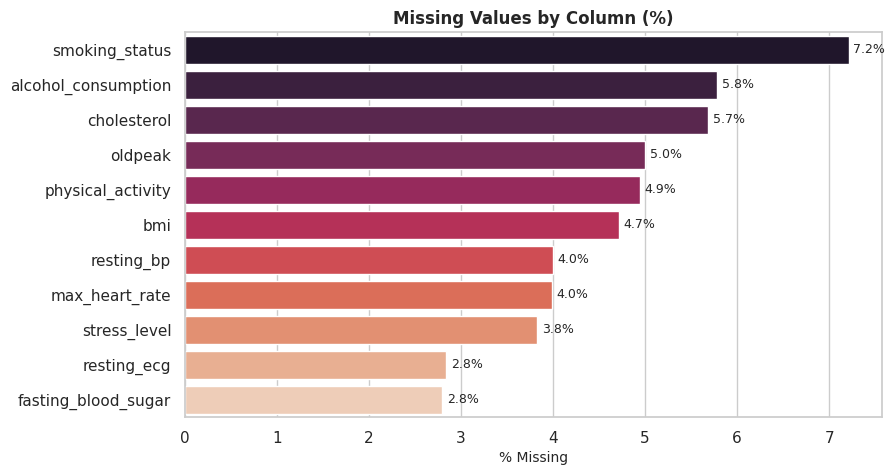

PosixPath('artifacts/figures/01_missingness_by_column.png')

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
missing_pct = df_raw.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]
sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index,
            palette="rocket", legend=False, ax=ax)
ax.set_title("Missing Values by Column (%)")
ax.set_xlabel("% Missing")
ax.set_ylabel("")
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.05, i, f"{v:.1f}%", va="center", fontsize=9)
save_and_show(fig, "missingness_by_column")

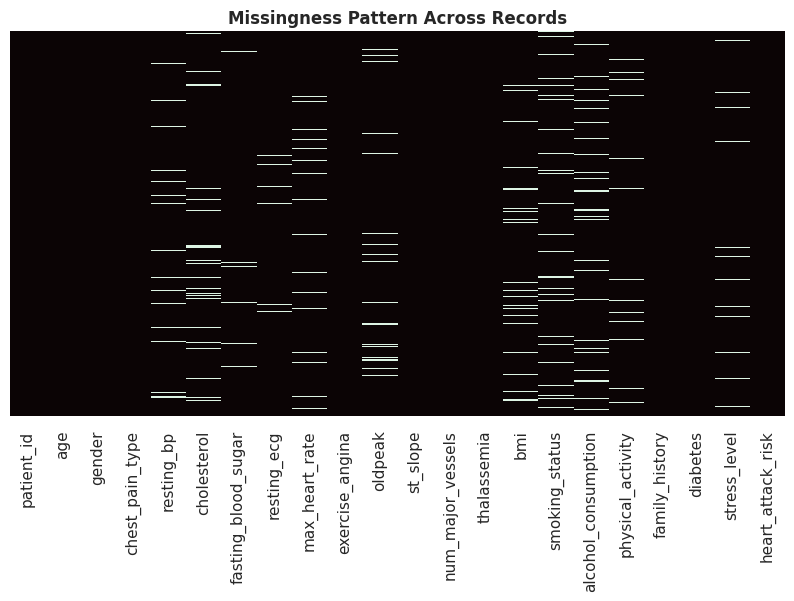

PosixPath('artifacts/figures/02_missingness_heatmap.png')

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_raw.isnull(), cbar=False, cmap="mako", yticklabels=False, ax=ax)
ax.set_title("Missingness Pattern Across Records")
save_and_show(fig, "missingness_heatmap")

## 3. Data Cleaning & Preprocessing

Two parallel tracks are kept, deliberately:

- **`df_eda`** — a fully imputed (median / mode, whole-dataset) copy used *only* for
  visualization and descriptive statistics, where leakage is not a modeling concern.
- **Modeling data** — imputers are fit on the *training split only* inside a
  `ColumnTransformer` (see Phase 7), which is the leak-free approach actually used to train
  and evaluate every model in this notebook.

The `patient_id` column is dropped (identifier, not predictive). Outliers are inspected but
not removed, since clinically plausible extreme values carry genuine risk signal.

In [11]:
df = df_raw.drop(columns=["patient_id"]).copy()

NUMERIC_COLS = ["age", "resting_bp", "cholesterol", "max_heart_rate", "oldpeak", "bmi", "stress_level"]
BINARY_COLS = ["fasting_blood_sugar", "exercise_angina", "family_history", "diabetes"]
DISCRETE_COLS = ["num_major_vessels"]
CATEGORICAL_COLS = ["gender", "chest_pain_type", "resting_ecg", "st_slope",
                     "thalassemia", "smoking_status", "alcohol_consumption", "physical_activity"]

print("Numeric      :", NUMERIC_COLS)
print("Binary       :", BINARY_COLS)
print("Discrete     :", DISCRETE_COLS)
print("Categorical  :", CATEGORICAL_COLS)
assert set(NUMERIC_COLS + BINARY_COLS + DISCRETE_COLS + CATEGORICAL_COLS + [TARGET]) == set(df.columns)

Numeric      : ['age', 'resting_bp', 'cholesterol', 'max_heart_rate', 'oldpeak', 'bmi', 'stress_level']
Binary       : ['fasting_blood_sugar', 'exercise_angina', 'family_history', 'diabetes']
Discrete     : ['num_major_vessels']
Categorical  : ['gender', 'chest_pain_type', 'resting_ecg', 'st_slope', 'thalassemia', 'smoking_status', 'alcohol_consumption', 'physical_activity']


In [12]:
# EDA-only fully imputed frame (NOT used for model training/evaluation)
df_eda = df.copy()
for c in NUMERIC_COLS + BINARY_COLS:
    df_eda[c] = df_eda[c].fillna(df_eda[c].median())
for c in CATEGORICAL_COLS:
    df_eda[c] = df_eda[c].fillna(df_eda[c].mode()[0])

print("Remaining missing values in df_eda:", df_eda.isnull().sum().sum())
save_csv(df_eda, "02_eda_imputed_dataset.csv")
df_eda.head()

Remaining missing values in df_eda: 0
Saved CSV artifact -> artifacts/csv/02_eda_imputed_dataset.csv  (7000 rows x 21 cols)


,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,...,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk
0,59,Male,Asymptomatic,105.0,154.0,0.0,ST-T Abnormality,186.0,1,1.0,...,1,Fixed Defect,23.5,Former,Heavy,Moderate,1,1,6.0,0
1,50,Male,Non-anginal Pain,102.0,180.0,0.0,Normal,183.0,0,2.9,...,0,Reversible Defect,19.3,Never,Moderate,High,0,0,8.0,0
2,61,Male,Atypical Angina,117.0,213.0,1.0,Normal,161.0,0,0.0,...,1,Fixed Defect,30.5,Never,Moderate,Low,1,1,2.0,1
3,73,Female,Atypical Angina,121.0,208.0,1.0,Normal,150.0,0,1.0,...,0,Normal,28.6,Former,Moderate,Moderate,0,0,4.0,0
4,49,Male,Non-anginal Pain,106.0,157.0,0.0,Normal,185.0,0,0.3,...,0,Reversible Defect,21.4,Former,Moderate,Moderate,0,0,5.0,0


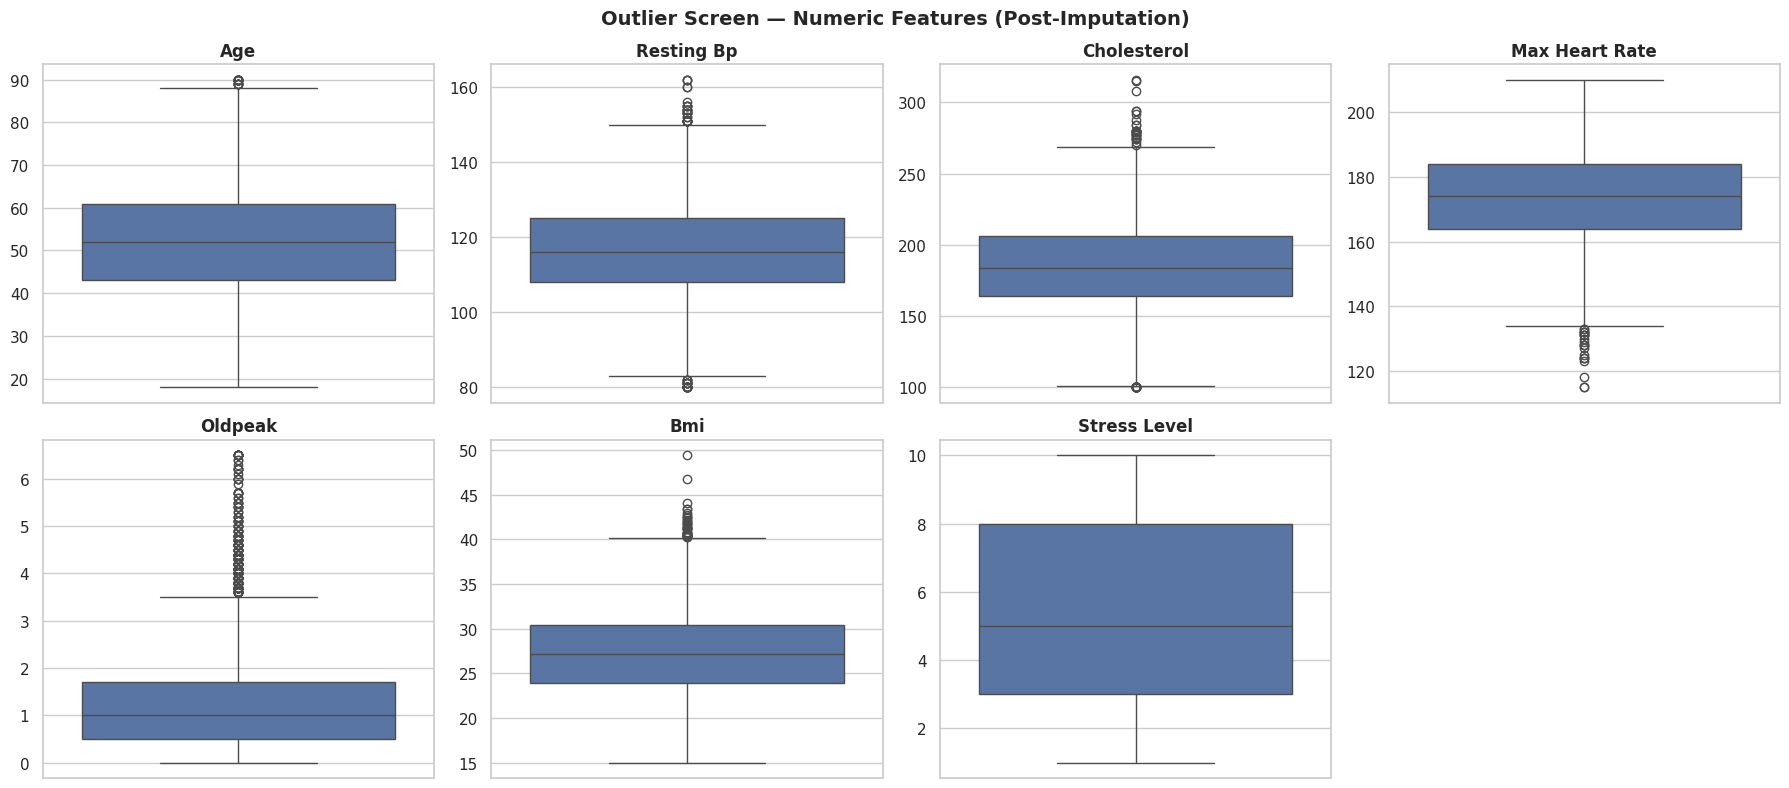

PosixPath('artifacts/figures/03_outlier_boxplots_grid.png')

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for i, col in enumerate(NUMERIC_COLS):
    sns.boxplot(y=df_eda[col], ax=axes[i], color="#4C72B0")
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_ylabel("")
for j in range(len(NUMERIC_COLS), len(axes)):
    axes[j].axis("off")
fig.suptitle("Outlier Screen — Numeric Features (Post-Imputation)", fontsize=14, fontweight="bold")
fig.tight_layout()
save_and_show(fig, "outlier_boxplots_grid")

## 4. Exploratory Data Analysis (EDA)

Univariate distributions, bivariate relationships with the target, correlation structure,
and multivariate views. Reusable plotting functions keep this section modular — the same
function is called once per column so every feature gets its own inline figure and its own
saved PNG artifact.

### 4.1 Univariate — Numeric Features

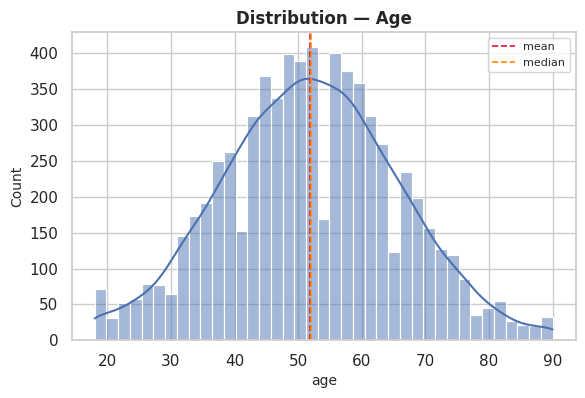

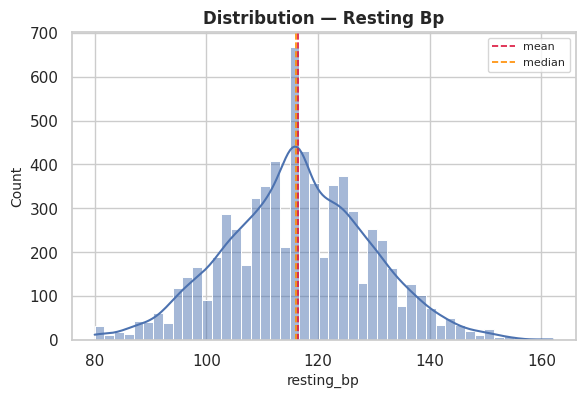

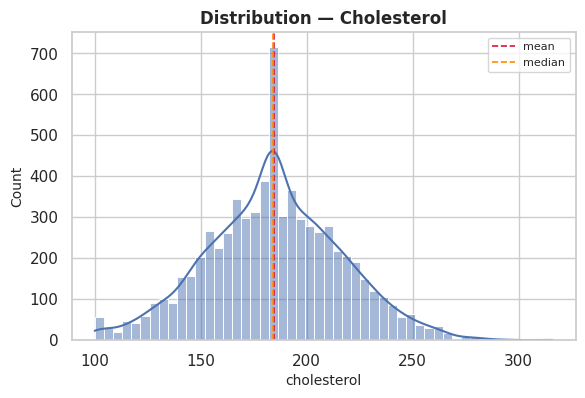

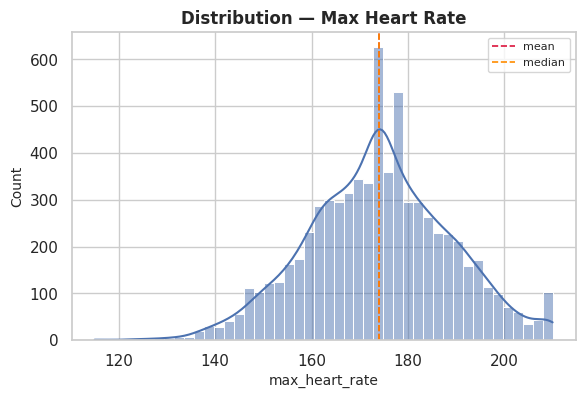

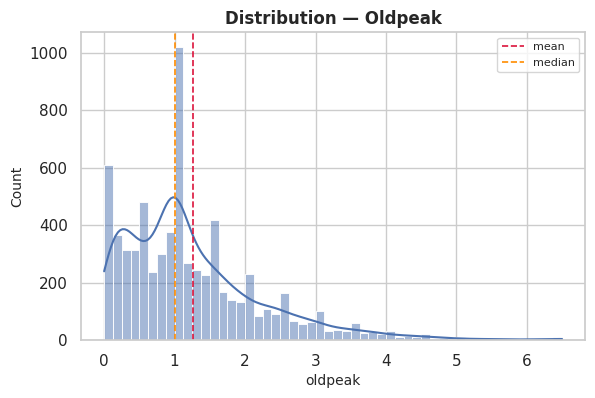

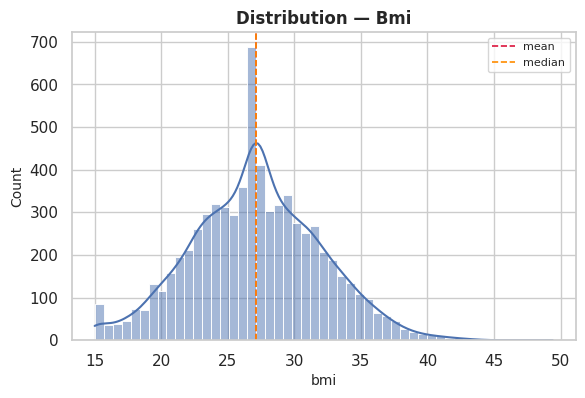

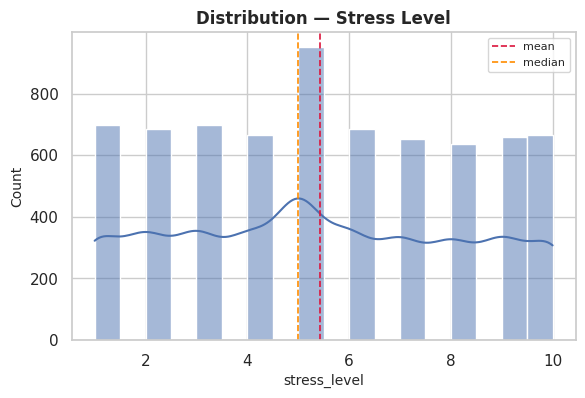

In [14]:
def plot_numeric_distribution(data, col):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    sns.histplot(data=data, x=col, kde=True, ax=ax, color="#4C72B0", edgecolor="white")
    ax.axvline(data[col].mean(), color="crimson", linestyle="--", linewidth=1.2, label="mean")
    ax.axvline(data[col].median(), color="darkorange", linestyle="--", linewidth=1.2, label="median")
    ax.set_title(f"Distribution — {col.replace('_', ' ').title()}")
    ax.legend(fontsize=8)
    save_and_show(fig, f"dist_{col}")

for c in NUMERIC_COLS:
    plot_numeric_distribution(df_eda, c)

### 4.2 Univariate — Categorical & Binary Features

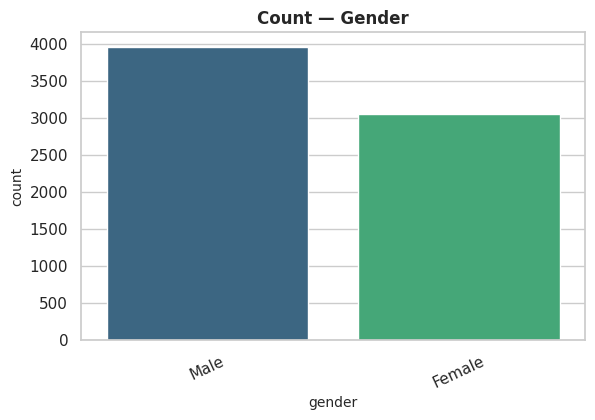

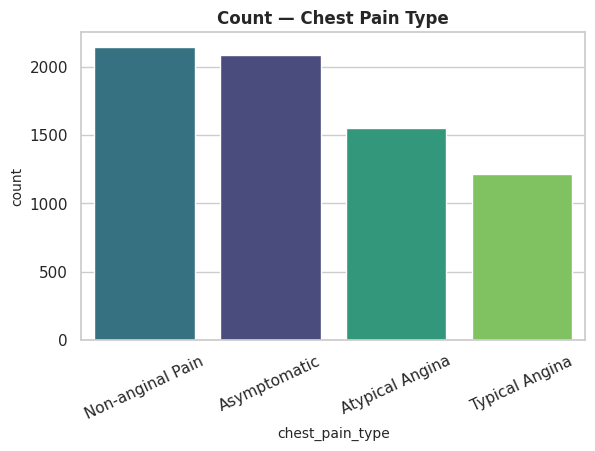

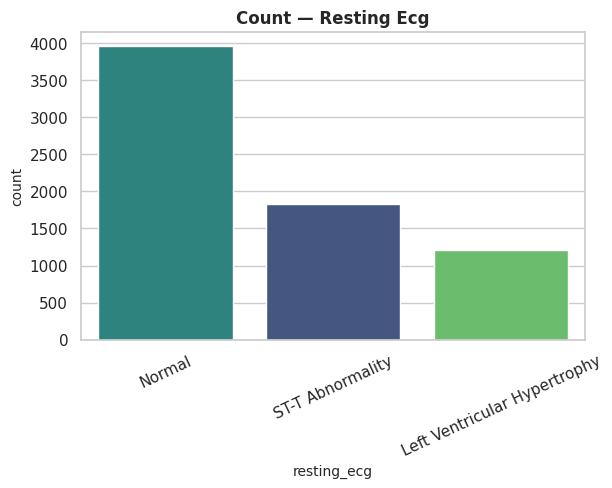

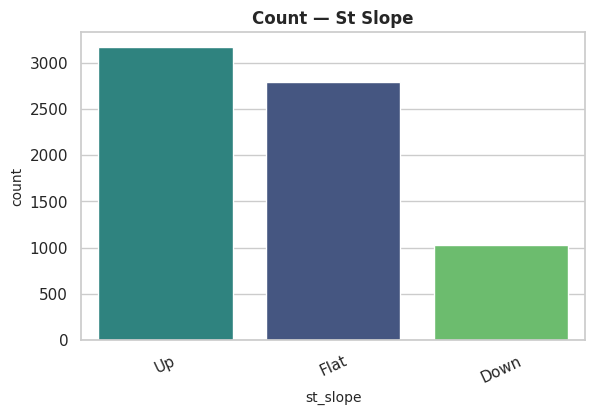

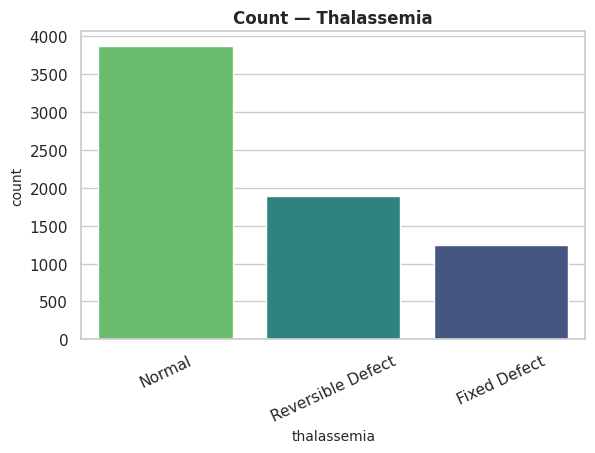

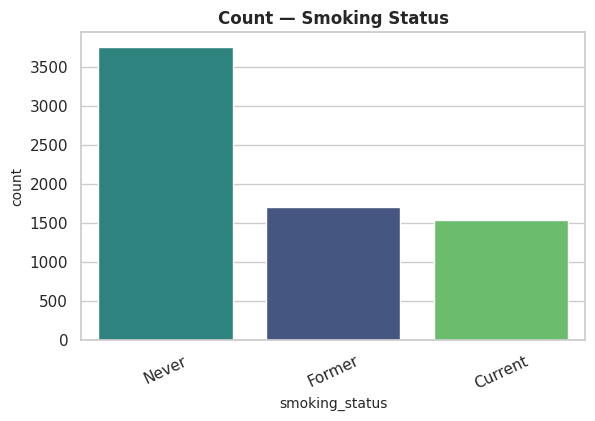

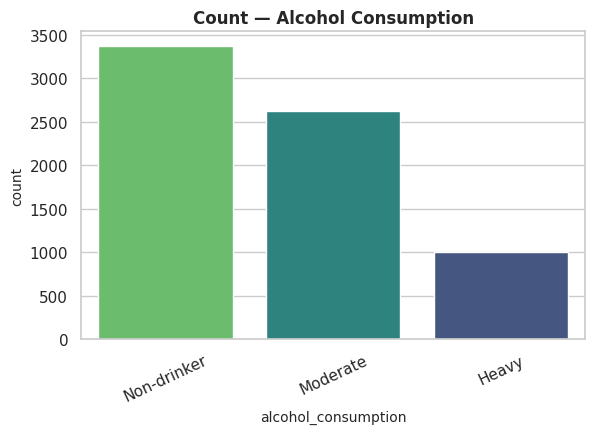

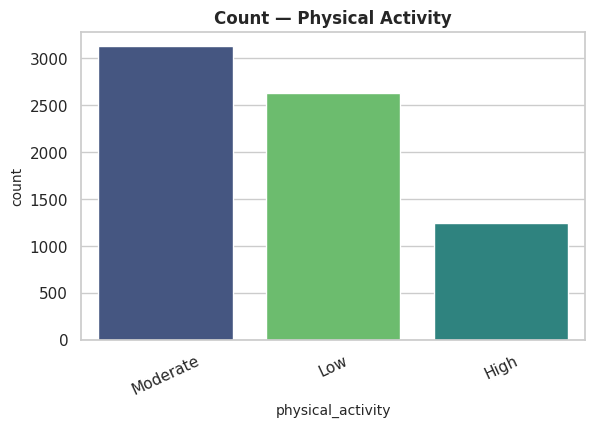

In [15]:
def plot_categorical_count(data, col):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, order=order, hue=col, palette="viridis", legend=False, ax=ax)
    ax.set_title(f"Count — {col.replace('_', ' ').title()}")
    ax.tick_params(axis="x", rotation=25)
    save_and_show(fig, f"count_{col}")

for c in CATEGORICAL_COLS:
    plot_categorical_count(df_eda, c)

### 4.3 Bivariate — Numeric Features vs Target

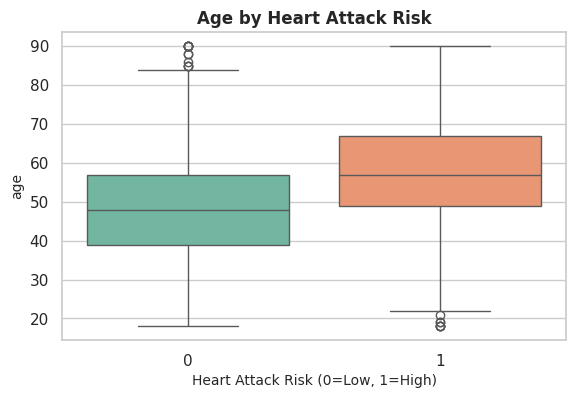

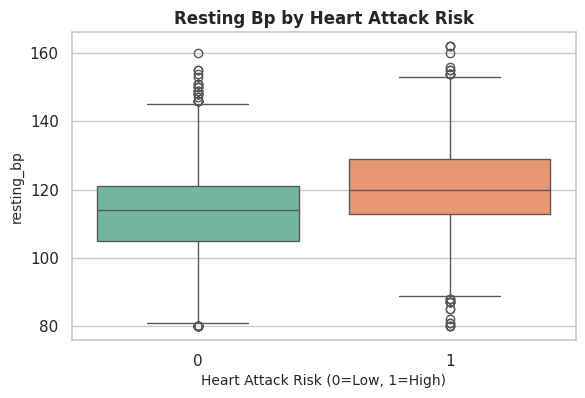

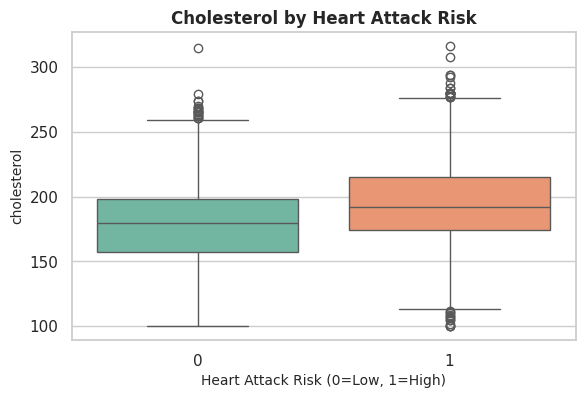

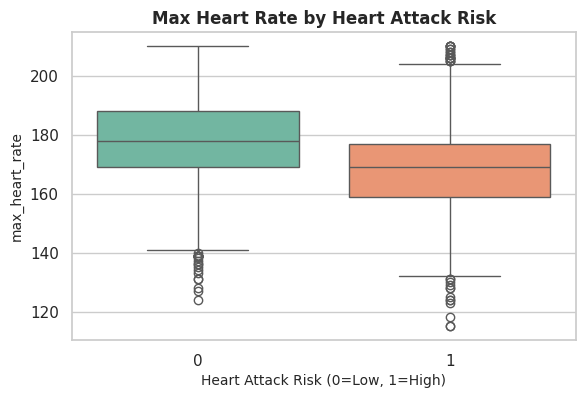

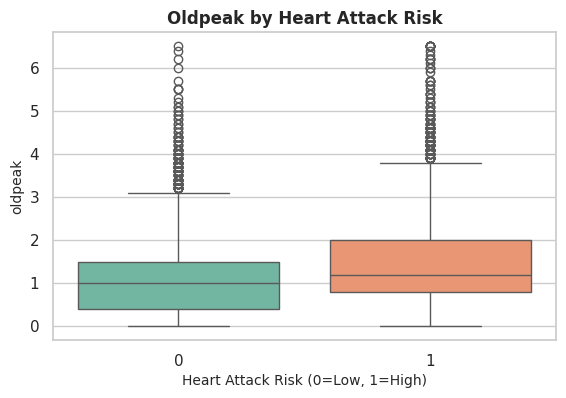

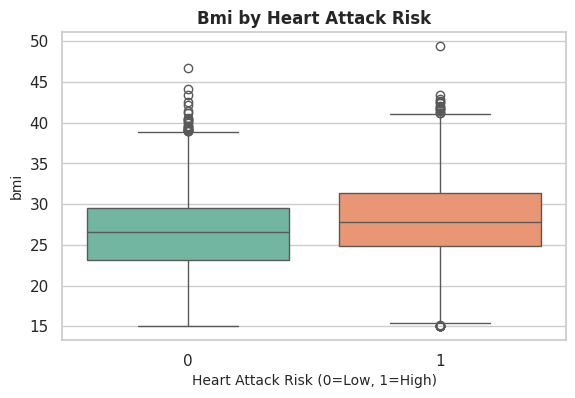

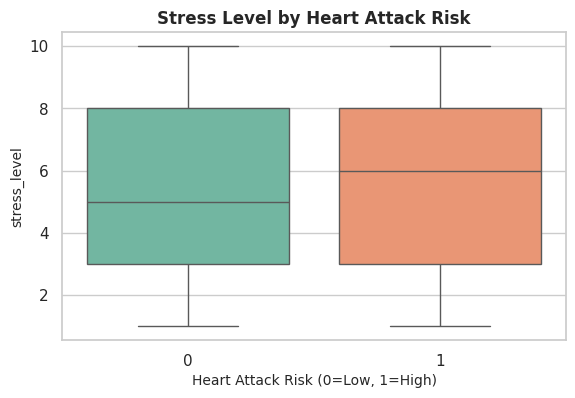

In [16]:
def plot_numeric_vs_target(data, col):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    sns.boxplot(data=data, x=TARGET, y=col, hue=TARGET, palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{col.replace('_', ' ').title()} by Heart Attack Risk")
    ax.set_xlabel("Heart Attack Risk (0=Low, 1=High)")
    save_and_show(fig, f"vs_target_{col}")

for c in NUMERIC_COLS:
    plot_numeric_vs_target(df_eda, c)

### 4.4 Bivariate — Categorical Features vs Target

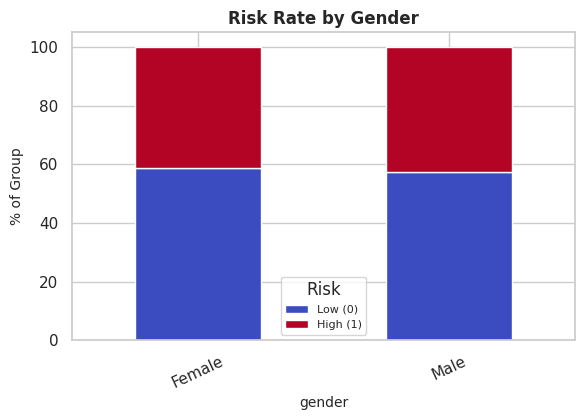

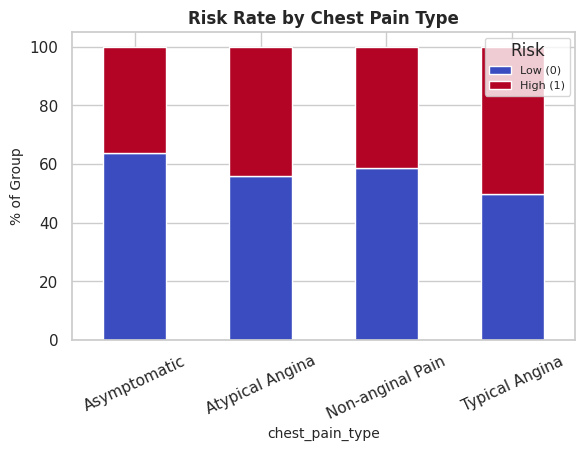

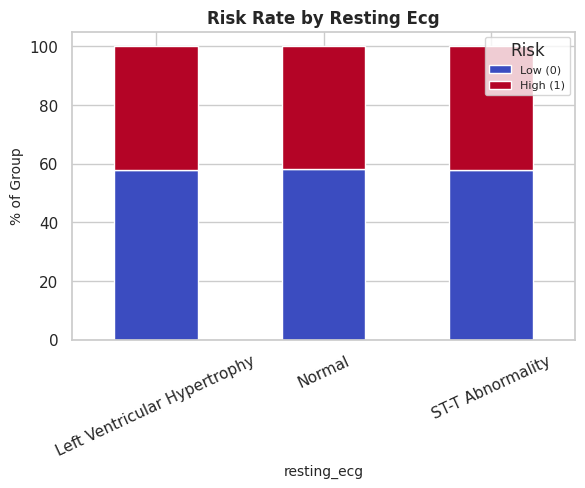

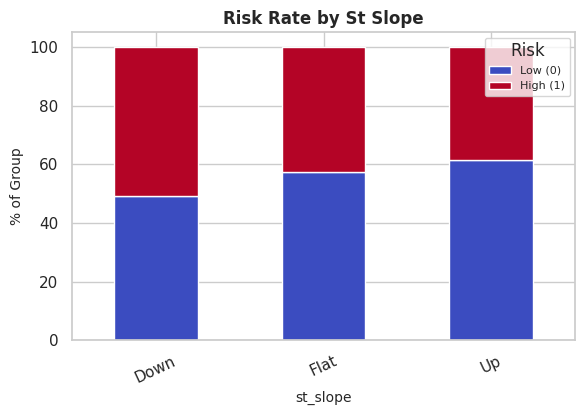

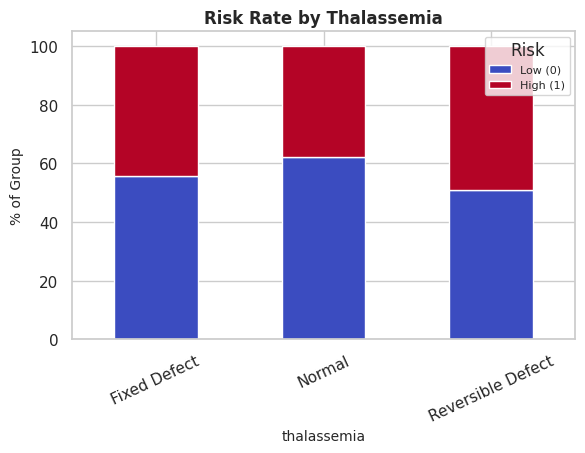

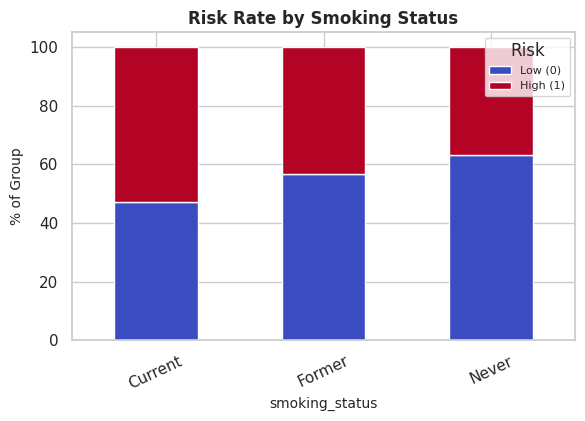

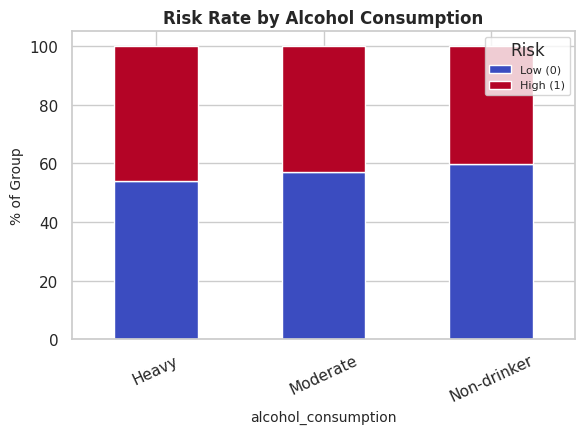

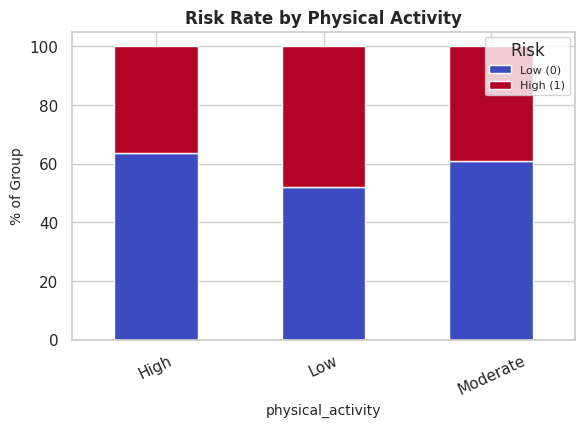

In [17]:
def plot_categorical_vs_target(data, col):
    ct = pd.crosstab(data[col], data[TARGET], normalize="index") * 100
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ct.plot(kind="bar", stacked=True, colormap="coolwarm", ax=ax)
    ax.set_title(f"Risk Rate by {col.replace('_', ' ').title()}")
    ax.set_ylabel("% of Group")
    ax.legend(title="Risk", labels=["Low (0)", "High (1)"], fontsize=8)
    ax.tick_params(axis="x", rotation=25)
    save_and_show(fig, f"target_rate_{col}")

for c in CATEGORICAL_COLS:
    plot_categorical_vs_target(df_eda, c)

### 4.5 Correlation Structure & Multivariate Views

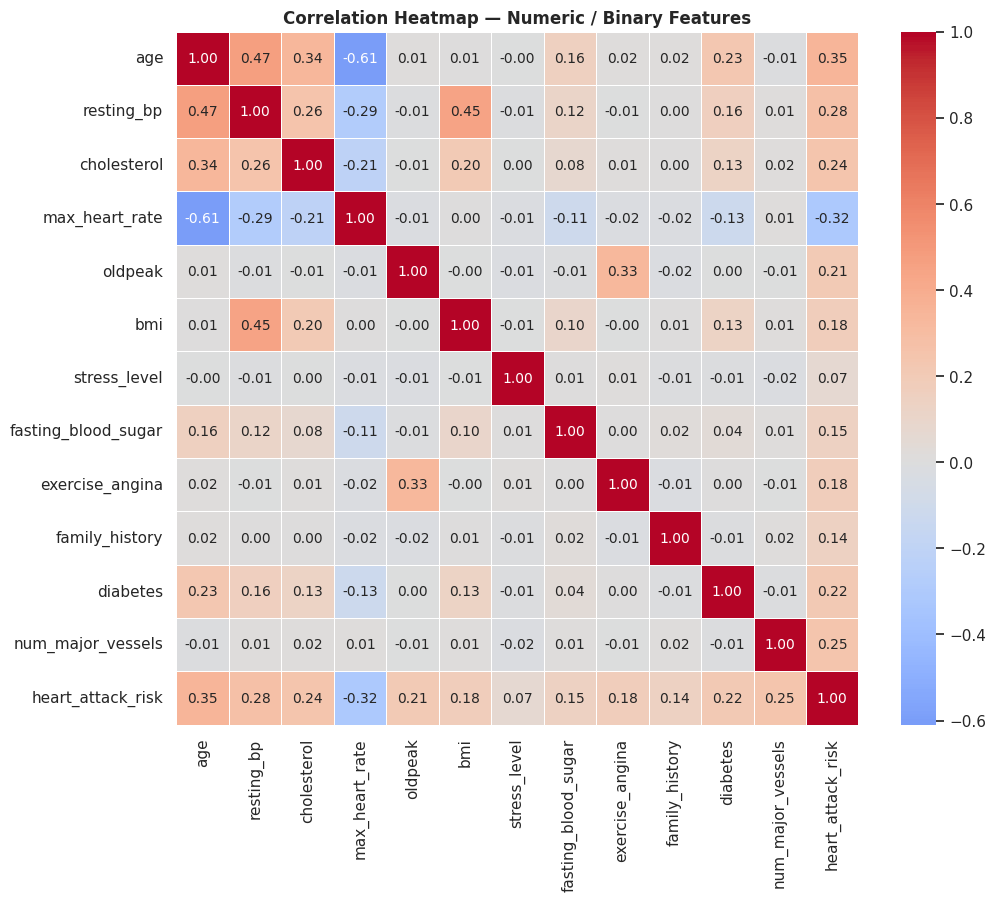

PosixPath('artifacts/figures/34_correlation_heatmap.png')

In [18]:
corr = df_eda[NUMERIC_COLS + BINARY_COLS + DISCRETE_COLS + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4, ax=ax)
ax.set_title("Correlation Heatmap — Numeric / Binary Features")
save_and_show(fig, "correlation_heatmap")

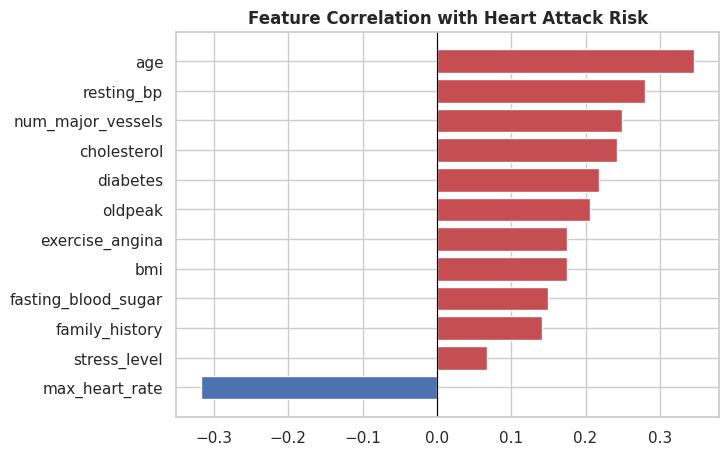

PosixPath('artifacts/figures/35_target_correlation_ranked.png')

In [19]:
target_corr = corr[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title("Feature Correlation with Heart Attack Risk")
ax.axvline(0, color="black", linewidth=0.8)
save_and_show(fig, "target_correlation_ranked")

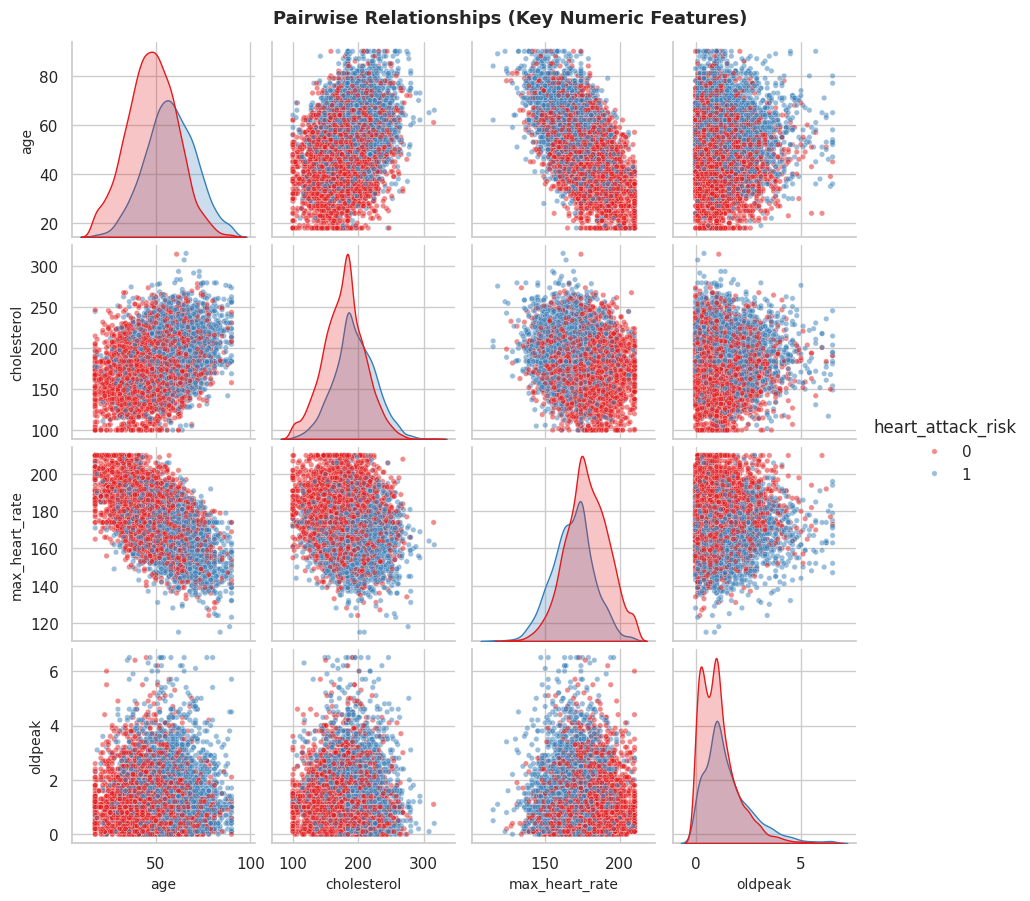

In [20]:
pair_cols = ["age", "cholesterol", "max_heart_rate", "oldpeak", TARGET]
g = sns.pairplot(df_eda[pair_cols], hue=TARGET, palette="Set1", diag_kind="kde",
                  plot_kws={"alpha": 0.5, "s": 15}, height=2.2)
g.fig.suptitle("Pairwise Relationships (Key Numeric Features)", y=1.02, fontsize=13, fontweight="bold")
_VIS_COUNTER["n"] += 1
g.fig.savefig(FIG_DIR / f"{_VIS_COUNTER['n']:02d}_pairplot_key_features.png", dpi=100, bbox_inches="tight")
plt.show()
plt.close(g.fig)

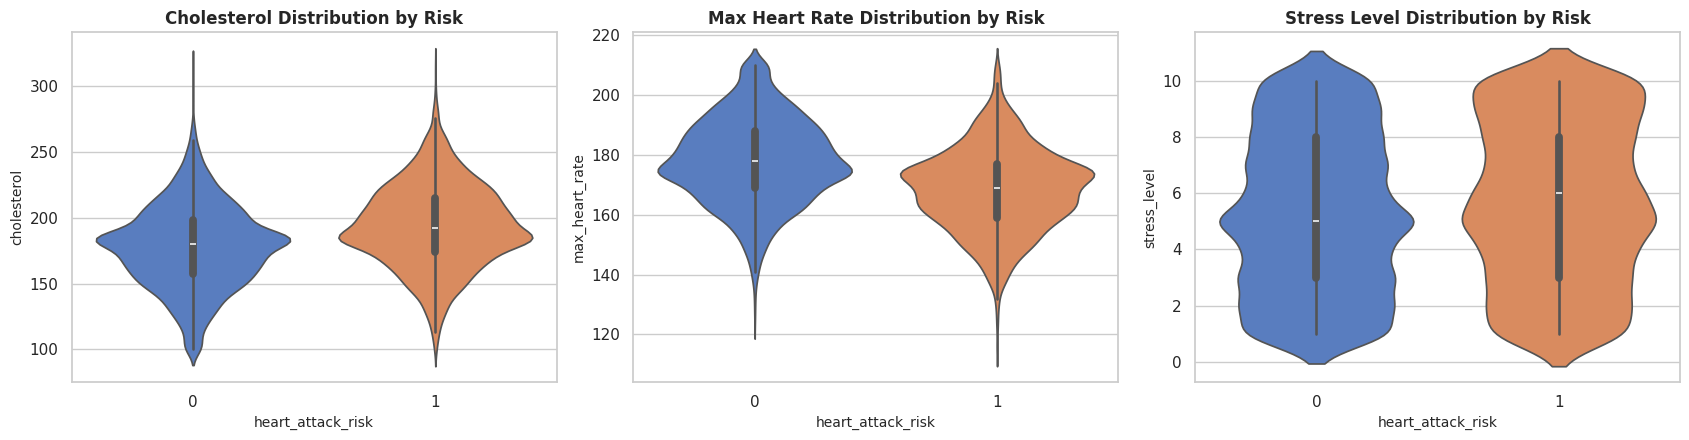

PosixPath('artifacts/figures/37_violin_grid_key_features.png')

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, ["cholesterol", "max_heart_rate", "stress_level"]):
    sns.violinplot(data=df_eda, x=TARGET, y=col, hue=TARGET, palette="muted", legend=False, ax=ax)
    ax.set_title(f"{col.replace('_',' ').title()} Distribution by Risk")
fig.tight_layout()
save_and_show(fig, "violin_grid_key_features")

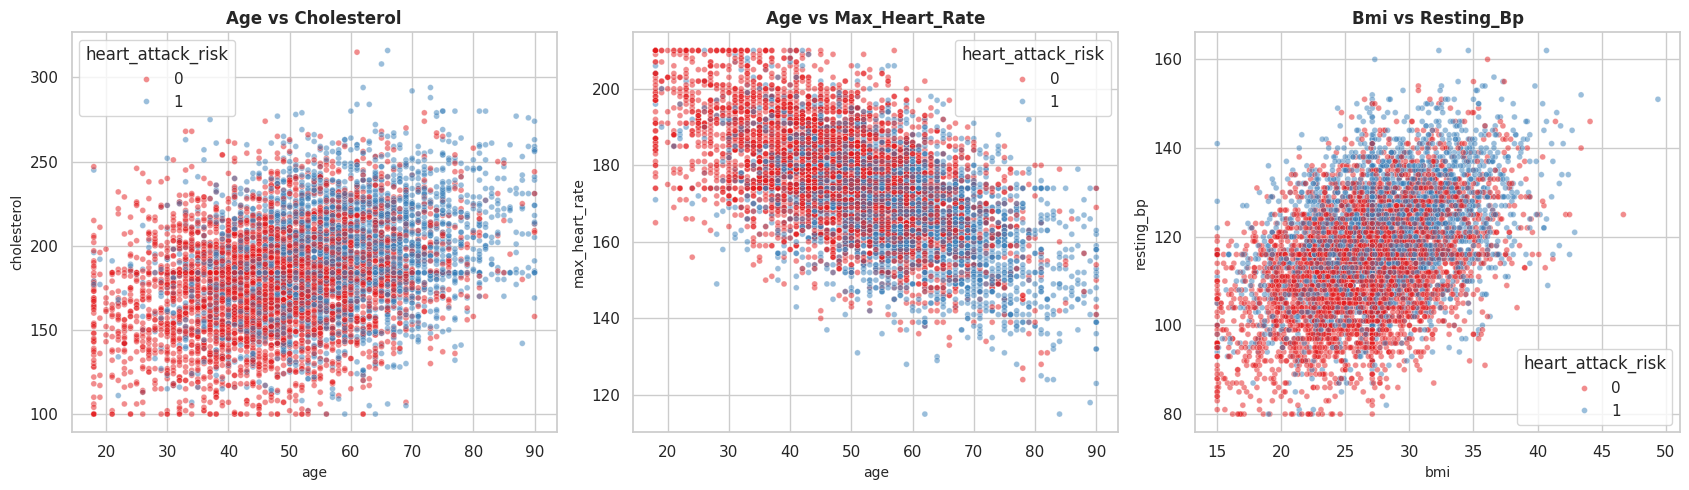

PosixPath('artifacts/figures/38_scatter_grid_relationships.png')

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
scatter_pairs = [("age", "cholesterol"), ("age", "max_heart_rate"), ("bmi", "resting_bp")]
for ax, (x, y) in zip(axes, scatter_pairs):
    sns.scatterplot(data=df_eda, x=x, y=y, hue=TARGET, palette="Set1", alpha=0.5, s=18, ax=ax)
    ax.set_title(f"{x.title()} vs {y.title()}")
fig.tight_layout()
save_and_show(fig, "scatter_grid_relationships")

## 5. Advanced & Granular Statistical Analysis

Formal hypothesis tests quantify what the EDA plots suggested visually:

- **Chi-square test of independence** for each categorical feature vs. target.
- **Independent-samples t-test** (Welch) for each numeric feature vs. target groups.
- **Variance Inflation Factor (VIF)** to flag multicollinearity among numeric predictors.
- **Skewness / kurtosis** to characterize distribution shape ahead of modeling.

In [23]:
chi2_results = []
for c in CATEGORICAL_COLS:
    ct = pd.crosstab(df_eda[c], df_eda[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    chi2_results.append({"feature": c, "chi2_stat": chi2, "p_value": p, "significant_0.05": p < 0.05})
chi2_df = pd.DataFrame(chi2_results).sort_values("p_value")
save_csv(chi2_df, "03_chi_square_test_results.csv")
chi2_df

Saved CSV artifact -> artifacts/csv/03_chi_square_test_results.csv  (8 rows x 4 cols)


,feature,chi2_stat,p_value,significant_0.05
5,smoking_status,112.616739,3.512254e-25,True
4,thalassemia,71.724377,2.662253e-16,True
7,physical_activity,64.049608,1.235391e-14,True
1,chest_pain_type,63.692885,9.548079e-14,True
3,st_slope,48.059670,3.664167e-11,True
6,alcohol_consumption,13.021087,1.487671e-03,True
0,gender,1.092734,2.958662e-01,False
2,resting_ecg,0.089905,9.560428e-01,False


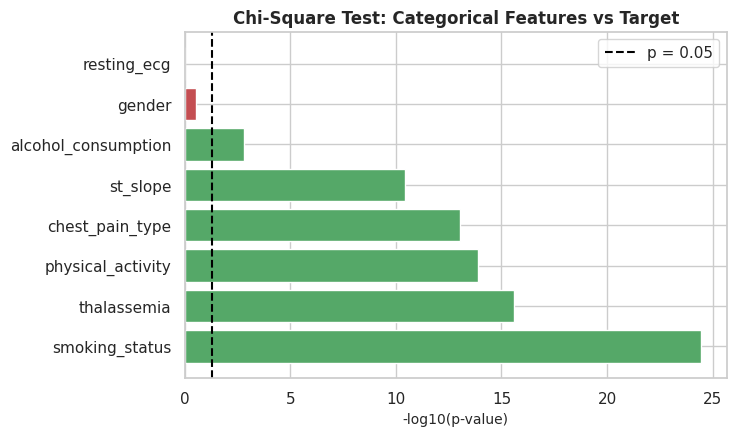

PosixPath('artifacts/figures/39_chi_square_significance.png')

In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#55A868" if s else "#C44E52" for s in chi2_df["significant_0.05"]]
ax.barh(chi2_df["feature"], -np.log10(chi2_df["p_value"].clip(lower=1e-300)), color=colors)
ax.axvline(-np.log10(0.05), color="black", linestyle="--", label="p = 0.05")
ax.set_xlabel("-log10(p-value)")
ax.set_title("Chi-Square Test: Categorical Features vs Target")
ax.legend()
save_and_show(fig, "chi_square_significance")

In [25]:
ttest_results = []
grp0 = df_eda[df_eda[TARGET] == 0]
grp1 = df_eda[df_eda[TARGET] == 1]
for c in NUMERIC_COLS:
    t_stat, p_val = stats.ttest_ind(grp0[c], grp1[c], equal_var=False)
    pooled_std = np.sqrt((grp0[c].std() ** 2 + grp1[c].std() ** 2) / 2)
    cohens_d = (grp1[c].mean() - grp0[c].mean()) / pooled_std
    ttest_results.append({"feature": c, "t_stat": t_stat, "p_value": p_val,
                           "cohens_d": cohens_d, "significant_0.05": p_val < 0.05})
ttest_df = pd.DataFrame(ttest_results).sort_values("p_value")
save_csv(ttest_df, "04_welch_ttest_results.csv")
ttest_df

Saved CSV artifact -> artifacts/csv/04_welch_ttest_results.csv  (7 rows x 5 cols)


,feature,t_stat,p_value,cohens_d,significant_0.05
0,age,-30.869642,5.004306e-195,0.747706,True
3,max_heart_rate,28.110896,4.259169e-164,-0.679191,True
1,resting_bp,-24.474498,1.691825e-126,0.592356,True
2,cholesterol,-20.921854,4.929376e-94,0.506822,True
4,oldpeak,-16.941415,9.251314e-63,0.417970,True
5,bmi,-14.835480,5.798555e-49,0.359730,True
6,stress_level,-5.647670,1.698006e-08,0.137022,True


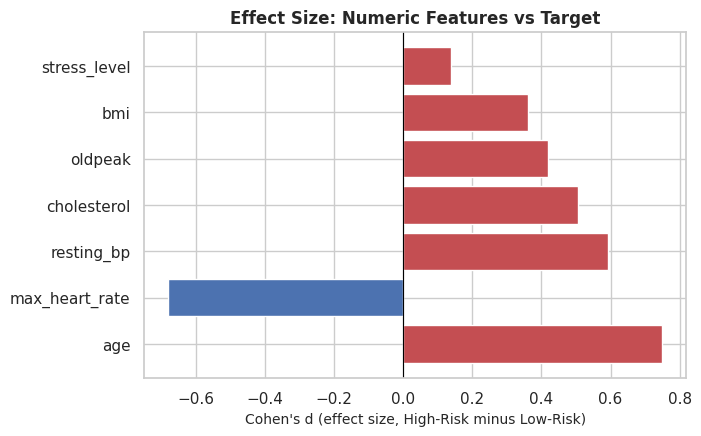

PosixPath('artifacts/figures/40_effect_size_cohens_d.png')

In [26]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#C44E52" if d > 0 else "#4C72B0" for d in ttest_df["cohens_d"]]
ax.barh(ttest_df["feature"], ttest_df["cohens_d"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cohen's d (effect size, High-Risk minus Low-Risk)")
ax.set_title("Effect Size: Numeric Features vs Target")
save_and_show(fig, "effect_size_cohens_d")

Saved CSV artifact -> artifacts/csv/05_variance_inflation_factors.csv  (7 rows x 2 cols)


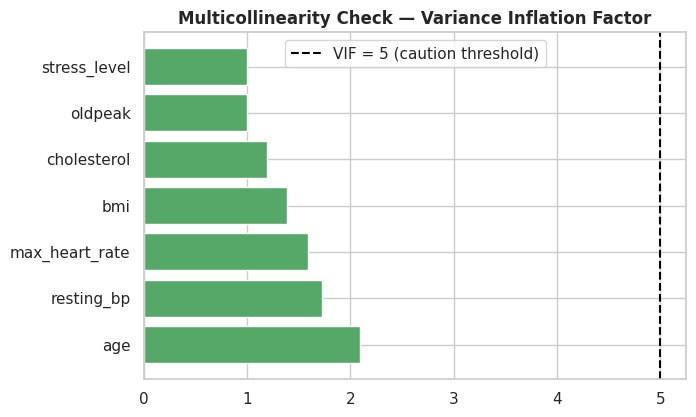

PosixPath('artifacts/figures/41_vif_multicollinearity.png')

In [27]:
vif_data = df_eda[NUMERIC_COLS].assign(const=1)
vif_df = pd.DataFrame({
    "feature": NUMERIC_COLS,
    "VIF": [variance_inflation_factor(vif_data.values, i) for i in range(len(NUMERIC_COLS))]
}).sort_values("VIF", ascending=False)
save_csv(vif_df, "05_variance_inflation_factors.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#C44E52" if v > 5 else "#55A868" for v in vif_df["VIF"]]
ax.barh(vif_df["feature"], vif_df["VIF"], color=colors)
ax.axvline(5, color="black", linestyle="--", label="VIF = 5 (caution threshold)")
ax.set_title("Multicollinearity Check — Variance Inflation Factor")
ax.legend()
save_and_show(fig, "vif_multicollinearity")

Saved CSV artifact -> artifacts/csv/06_skewness_kurtosis.csv  (7 rows x 3 cols)


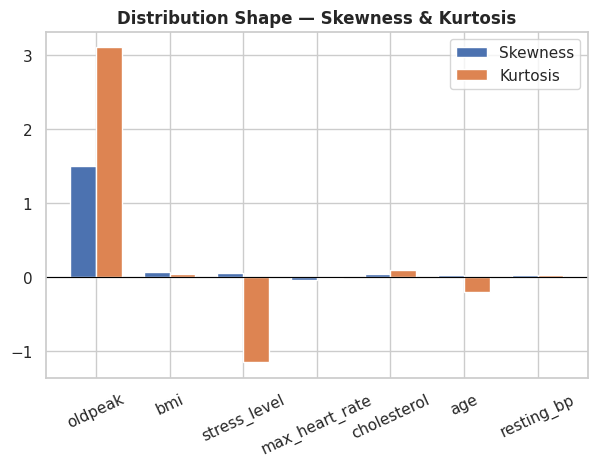

PosixPath('artifacts/figures/42_skewness_kurtosis.png')

In [28]:
shape_df = pd.DataFrame({
    "feature": NUMERIC_COLS,
    "skewness": [stats.skew(df_eda[c]) for c in NUMERIC_COLS],
    "kurtosis": [stats.kurtosis(df_eda[c]) for c in NUMERIC_COLS],
}).sort_values("skewness", key=abs, ascending=False)
save_csv(shape_df, "06_skewness_kurtosis.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(shape_df))
width = 0.35
ax.bar(x - width/2, shape_df["skewness"], width, label="Skewness", color="#4C72B0")
ax.bar(x + width/2, shape_df["kurtosis"], width, label="Kurtosis", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(shape_df["feature"], rotation=25)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Distribution Shape — Skewness & Kurtosis")
ax.legend()
save_and_show(fig, "skewness_kurtosis")

## 6. Feature Engineering

A reusable `ClinicalFeatureBuilder` (a scikit-learn `TransformerMixin`) derives clinically
motivated features using **fixed, literature-based thresholds** (not statistics learned from
the data), so it can safely be applied before the train/test split without introducing
leakage — only the *imputers and scaler* downstream are fit on the training fold alone.

New features:
- `age_group` — banded age (young / middle-aged / senior / elderly)
- `bp_category` — resting BP bucketed by standard hypertension staging
- `cholesterol_category` — desirable / borderline / high
- `bmi_category` — WHO BMI classification
- `heart_rate_reserve` — theoretical max HR (220-age) minus observed max HR
- `composite_risk_score` — weighted sum of standardized clinical risk indicators
- `comorbidity_count` — count of family history + diabetes + fasting blood sugar + smoking

In [29]:
class ClinicalFeatureBuilder(BaseEstimator, TransformerMixin):
    # Deterministic clinical feature derivation. Uses fixed thresholds only -> stateless,
    # so fit() is a no-op and there is no train/test leakage risk.

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["age_group"] = pd.cut(
            X["age"], bins=[0, 35, 50, 65, 120],
            labels=["young_adult", "middle_aged", "senior", "elderly"]
        )

        X["bp_category"] = pd.cut(
            X["resting_bp"], bins=[0, 120, 129, 139, 300],
            labels=["normal", "elevated", "stage1_hypertension", "stage2_hypertension"]
        )

        X["cholesterol_category"] = pd.cut(
            X["cholesterol"], bins=[0, 200, 239, 1000],
            labels=["desirable", "borderline_high", "high"]
        )

        X["bmi_category"] = pd.cut(
            X["bmi"], bins=[0, 18.5, 25, 30, 100],
            labels=["underweight", "normal", "overweight", "obese"]
        )

        X["heart_rate_reserve"] = (220 - X["age"]) - X["max_heart_rate"]

        risk_components = pd.concat([
            (X["age"] - 50) / 15,
            (X["resting_bp"] - 120) / 15,
            (X["cholesterol"] - 200) / 40,
            (X["bmi"] - 25) / 5,
            X["exercise_angina"].astype(float) * 1.5,
            X["oldpeak"] / 2,
        ], axis=1)
        X["composite_risk_score"] = risk_components.mean(axis=1)

        X["comorbidity_count"] = (
            X["family_history"].fillna(0)
            + X["diabetes"].fillna(0)
            + X["fasting_blood_sugar"].fillna(0)
            + (X["smoking_status"] == "Current").astype(float)
        )

        return X

    def get_feature_names_out(self, input_features=None):
        base = list(input_features) if input_features is not None else []
        return base + ["age_group", "bp_category", "cholesterol_category", "bmi_category",
                        "heart_rate_reserve", "composite_risk_score", "comorbidity_count"]


feature_builder = ClinicalFeatureBuilder()
df_engineered = feature_builder.transform(df)
print("New shape after feature engineering:", df_engineered.shape)
df_engineered.head()

New shape after feature engineering: (7000, 28)


,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,...,diabetes,stress_level,heart_attack_risk,age_group,bp_category,cholesterol_category,bmi_category,heart_rate_reserve,composite_risk_score,comorbidity_count
0,59,Male,Asymptomatic,105.0,154.0,0.0,ST-T Abnormality,186.0,1,1.0,...,1,6.0,0,senior,normal,desirable,normal,-25.0,0.025000,2.0
1,50,Male,Non-anginal Pain,102.0,180.0,0.0,Normal,183.0,0,2.9,...,0,8.0,0,middle_aged,normal,desirable,normal,-13.0,-0.231667,0.0
2,61,Male,Atypical Angina,117.0,213.0,1.0,Normal,161.0,0,0.0,...,1,2.0,1,senior,normal,borderline_high,obese,-2.0,0.326389,3.0
3,73,Female,Atypical Angina,121.0,208.0,1.0,Normal,150.0,0,1.0,...,0,4.0,0,elderly,elevated,borderline_high,overweight,-3.0,0.503333,1.0
4,49,Male,Non-anginal Pain,106.0,157.0,0.0,Normal,185.0,0,0.3,...,0,NaN,0,middle_aged,normal,desirable,normal,-14.0,-0.440833,0.0


Saved CSV artifact -> artifacts/csv/07_feature_engineered_dataset.csv  (7000 rows x 28 cols)


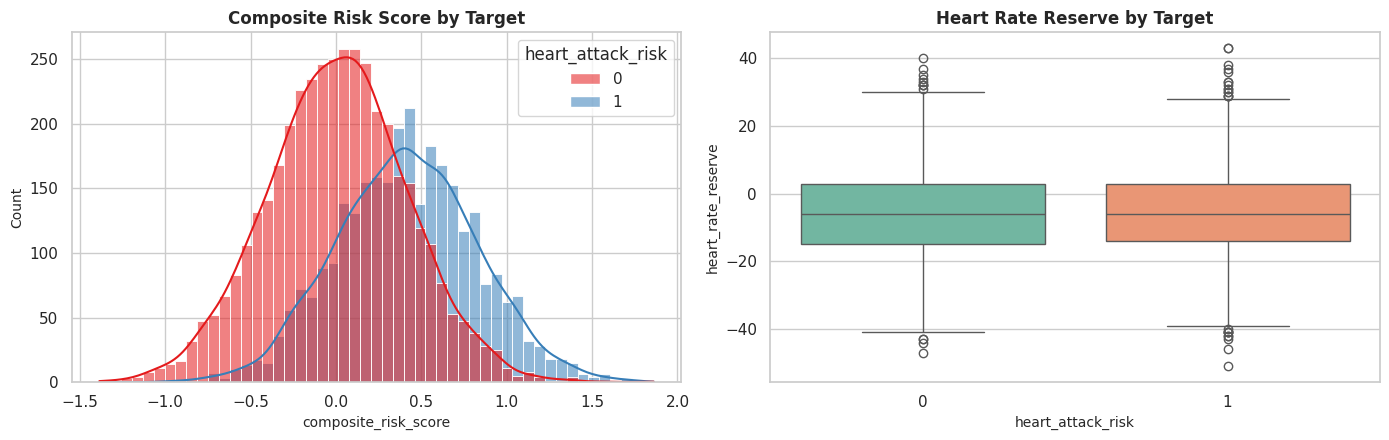

PosixPath('artifacts/figures/43_engineered_numeric_features.png')

In [30]:
ENGINEERED_NUMERIC = ["heart_rate_reserve", "composite_risk_score", "comorbidity_count"]
ENGINEERED_CATEGORICAL = ["age_group", "bp_category", "cholesterol_category", "bmi_category"]

save_csv(df_engineered, "07_feature_engineered_dataset.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(data=df_engineered.dropna(subset=["composite_risk_score"]), x="composite_risk_score",
             hue=TARGET, kde=True, palette="Set1", ax=axes[0], alpha=0.55)
axes[0].set_title("Composite Risk Score by Target")
sns.boxplot(data=df_engineered, x=TARGET, y="heart_rate_reserve", hue=TARGET,
            palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Heart Rate Reserve by Target")
fig.tight_layout()
save_and_show(fig, "engineered_numeric_features")

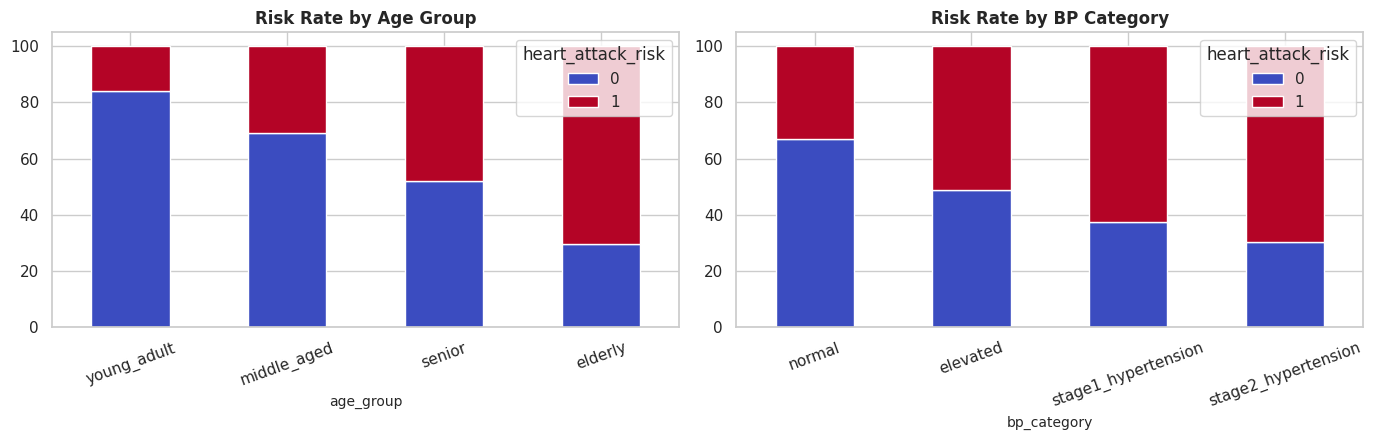

PosixPath('artifacts/figures/44_engineered_categorical_features.png')

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ct1 = pd.crosstab(df_engineered["age_group"], df_engineered[TARGET], normalize="index") * 100
ct1.plot(kind="bar", stacked=True, colormap="coolwarm", ax=axes[0])
axes[0].set_title("Risk Rate by Age Group")
axes[0].tick_params(axis="x", rotation=20)

ct2 = pd.crosstab(df_engineered["bp_category"], df_engineered[TARGET], normalize="index") * 100
ct2.plot(kind="bar", stacked=True, colormap="coolwarm", ax=axes[1])
axes[1].set_title("Risk Rate by BP Category")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
save_and_show(fig, "engineered_categorical_features")

## 7. Train/Test Split & Leak-Free Preprocessing Pipeline

A single stratified 80/20 split is used everywhere downstream. All imputation, encoding,
and scaling statistics are fit **exclusively on the training fold** via a `ColumnTransformer`
wrapped in a `Pipeline`, then applied to the test fold — the standard leak-free pattern.

Train shape: (5600, 27)  Test shape: (1400, 27)


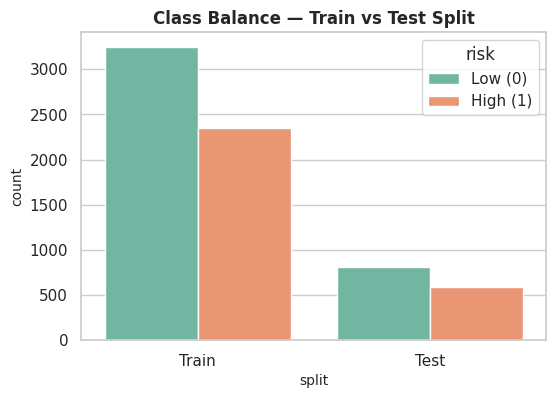

PosixPath('artifacts/figures/45_train_test_class_balance.png')

In [32]:
X = df_engineered.drop(columns=[TARGET])
y = df_engineered[TARGET]

ALL_NUMERIC = NUMERIC_COLS + BINARY_COLS + DISCRETE_COLS + ENGINEERED_NUMERIC
ALL_CATEGORICAL = CATEGORICAL_COLS + ENGINEERED_CATEGORICAL

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

fig, ax = plt.subplots(figsize=(6, 4))
split_df = pd.DataFrame({
    "split": ["Train", "Train", "Test", "Test"],
    "risk": ["Low (0)", "High (1)", "Low (0)", "High (1)"],
    "count": [
        (y_train == 0).sum(), (y_train == 1).sum(),
        (y_test == 0).sum(), (y_test == 1).sum(),
    ],
})
sns.barplot(data=split_df, x="split", y="count", hue="risk", palette="Set2", ax=ax)
ax.set_title("Class Balance — Train vs Test Split")
save_and_show(fig, "train_test_class_balance")

In [33]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, ALL_NUMERIC),
    ("cat", categorical_pipeline, ALL_CATEGORICAL),
], remainder="drop")

preprocessor.fit(X_train)
feature_names_out = preprocessor.get_feature_names_out()
print(f"Total engineered feature space after encoding: {len(feature_names_out)} columns")

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)
print("Transformed train shape:", X_train_t.shape, " Transformed test shape:", X_test_t.shape)

Total engineered feature space after encoding: 54 columns


Transformed train shape: (5600, 54)  Transformed test shape: (1400, 54)


## 8. Baseline Models

Five interpretable, low-complexity classifiers establish a performance floor: Logistic
Regression, K-Nearest Neighbors, Decision Tree, Gaussian Naive Bayes, and a linear SVM.
A single `evaluate_model` utility fits, scores, and logs every model consistently across
all tiers of this notebook (baseline -> advanced -> tuned), keeping the code DRY.

In [34]:
MODEL_RESULTS = []
TRAINED_MODELS = {}
MODEL_PROBAS = {}

def evaluate_model(name, model, tier, X_tr=X_train_t, y_tr=y_train, X_te=X_test_t, y_te=y_test):
    # Fit a model, score it on the held-out test fold, and log metrics + probabilities.
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_te)

    metrics = {
        "model": name, "tier": tier,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, y_proba),
        "train_accuracy": accuracy_score(y_tr, model.predict(X_tr)),
    }
    MODEL_RESULTS.append(metrics)
    TRAINED_MODELS[name] = model
    MODEL_PROBAS[name] = y_proba
    print(f"{name:28s} | Test Acc: {metrics['accuracy']:.4f} | F1: {metrics['f1']:.4f} "
          f"| ROC-AUC: {metrics['roc_auc']:.4f} | Train Acc: {metrics['train_accuracy']:.4f}")
    return model, y_proba

In [35]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB(),
    "Linear SVM": SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
}

print("=== Baseline Model Results ===")
for name, model in baseline_models.items():
    evaluate_model(name, model, tier="baseline")

=== Baseline Model Results ===
Logistic Regression          | Test Acc: 0.7857 | F1: 0.7317 | ROC-AUC: 0.8690 | Train Acc: 0.7902


K-Nearest Neighbors          | Test Acc: 0.7543 | F1: 0.6546 | ROC-AUC: 0.8260 | Train Acc: 0.7782
Decision Tree                | Test Acc: 0.7350 | F1: 0.6436 | ROC-AUC: 0.8128 | Train Acc: 0.7716
Gaussian Naive Bayes         | Test Acc: 0.7379 | F1: 0.6844 | ROC-AUC: 0.7945 | Train Acc: 0.7330


Linear SVM                   | Test Acc: 0.7879 | F1: 0.7341 | ROC-AUC: 0.8700 | Train Acc: 0.7923


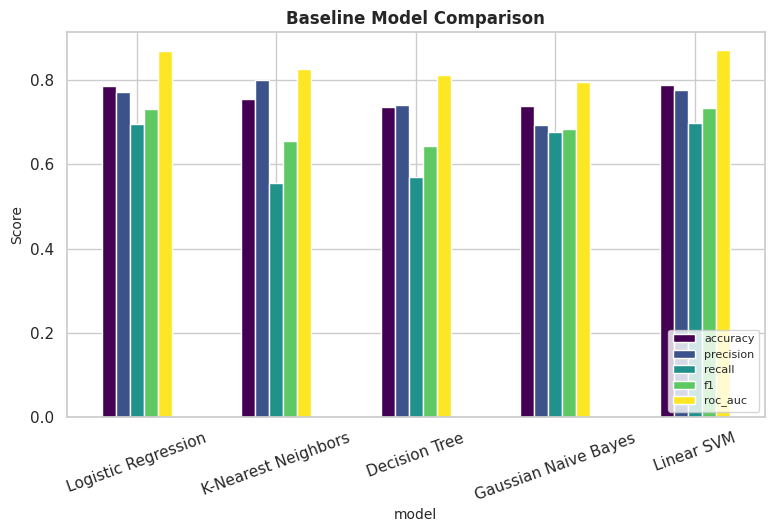

PosixPath('artifacts/figures/46_baseline_model_comparison.png')

In [36]:
baseline_df = pd.DataFrame([m for m in MODEL_RESULTS if m["tier"] == "baseline"])
fig, ax = plt.subplots(figsize=(9, 5))
baseline_df.set_index("model")[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(
    kind="bar", ax=ax, colormap="viridis"
)
ax.set_title("Baseline Model Comparison")
ax.set_ylabel("Score")
ax.legend(loc="lower right", fontsize=8)
ax.tick_params(axis="x", rotation=20)
save_and_show(fig, "baseline_model_comparison")

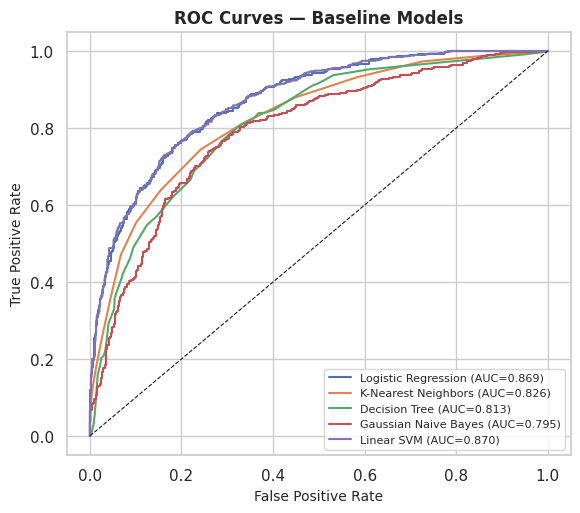

PosixPath('artifacts/figures/47_baseline_roc_curves.png')

In [37]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name in baseline_models:
    fpr, tpr, _ = roc_curve(y_test, MODEL_PROBAS[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, MODEL_PROBAS[name]):.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Baseline Models")
ax.legend(fontsize=8)
save_and_show(fig, "baseline_roc_curves")

## 9. Advanced Models

Ensemble and gradient-boosting methods typically outperform the baseline tier on tabular
clinical data: Random Forest, Extra Trees, AdaBoost, Gradient Boosting, XGBoost (GPU-aware),
and LightGBM.

In [38]:
advanced_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(n_estimators=150, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, max_depth=3, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.08, eval_metric="logloss",
        tree_method=XGB_TREE_METHOD, device=XGB_DEVICE, random_state=RANDOM_STATE
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.08, random_state=RANDOM_STATE, verbose=-1
    ),
}

print("=== Advanced Model Results ===")
for name, model in advanced_models.items():
    evaluate_model(name, model, tier="advanced")

=== Advanced Model Results ===


Random Forest                | Test Acc: 0.7743 | F1: 0.7090 | ROC-AUC: 0.8577 | Train Acc: 0.9232


Extra Trees                  | Test Acc: 0.7693 | F1: 0.6961 | ROC-AUC: 0.8474 | Train Acc: 0.9136


AdaBoost                     | Test Acc: 0.7843 | F1: 0.7308 | ROC-AUC: 0.8641 | Train Acc: 0.7914


Gradient Boosting            | Test Acc: 0.7836 | F1: 0.7278 | ROC-AUC: 0.8633 | Train Acc: 0.8384


XGBoost                      | Test Acc: 0.7900 | F1: 0.7394 | ROC-AUC: 0.8546 | Train Acc: 0.9155


LightGBM                     | Test Acc: 0.7800 | F1: 0.7284 | ROC-AUC: 0.8567 | Train Acc: 0.9207


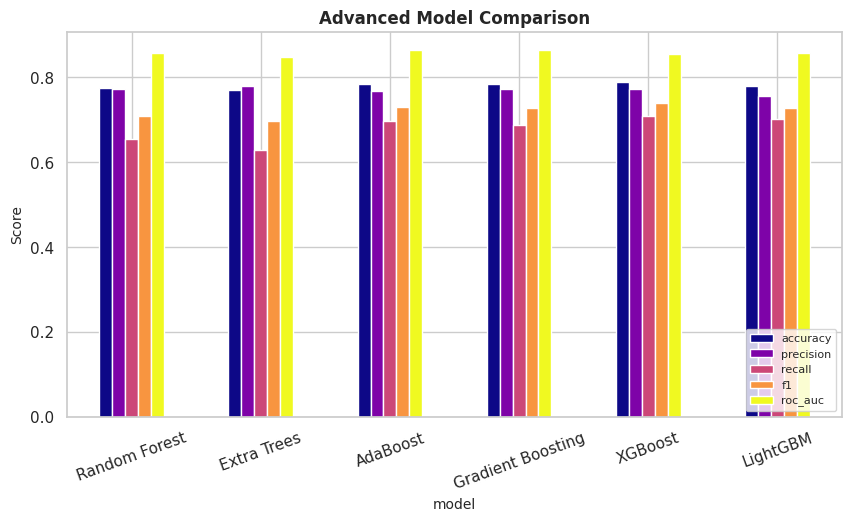

PosixPath('artifacts/figures/48_advanced_model_comparison.png')

In [39]:
advanced_df = pd.DataFrame([m for m in MODEL_RESULTS if m["tier"] == "advanced"])
fig, ax = plt.subplots(figsize=(10, 5))
advanced_df.set_index("model")[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(
    kind="bar", ax=ax, colormap="plasma"
)
ax.set_title("Advanced Model Comparison")
ax.set_ylabel("Score")
ax.legend(loc="lower right", fontsize=8)
ax.tick_params(axis="x", rotation=20)
save_and_show(fig, "advanced_model_comparison")

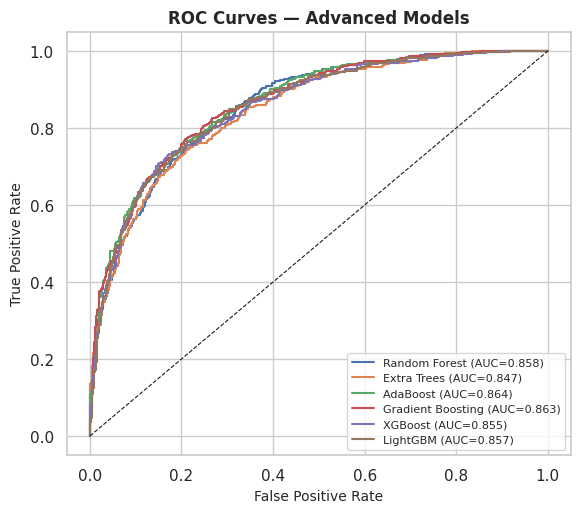

PosixPath('artifacts/figures/49_advanced_roc_curves.png')

In [40]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name in advanced_models:
    fpr, tpr, _ = roc_curve(y_test, MODEL_PROBAS[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, MODEL_PROBAS[name]):.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Advanced Models")
ax.legend(fontsize=8)
save_and_show(fig, "advanced_roc_curves")

## 10. Hyperparameter Tuning — Top 3 Models

The three models with the highest test ROC-AUC so far are selected automatically and tuned
with `RandomizedSearchCV` (5-fold stratified CV, 25 iterations, optimizing ROC-AUC). Tuned
models are re-evaluated on the untouched test fold and logged under the `tuned` tier.

In [41]:
all_so_far = pd.DataFrame(MODEL_RESULTS)
top3_names = all_so_far.sort_values("roc_auc", ascending=False)["model"].head(3).tolist()
print("Top 3 models selected for tuning:", top3_names)

ALL_MODEL_INSTANCES = {**baseline_models, **advanced_models}

PARAM_GRIDS = {
    "Logistic Regression": {
        "C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
        "penalty": ["l2"],
        "solver": ["lbfgs", "liblinear"],
    },
    "K-Nearest Neighbors": {
        "n_neighbors": list(range(5, 41, 2)),
        "weights": ["uniform", "distance"],
        "p": [1, 2],
    },
    "Decision Tree": {
        "max_depth": [3, 4, 5, 6, 8, 10, 12, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8],
    },
    "Linear SVM": {
        "C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    },
    "Random Forest": {
        "n_estimators": [100, 150, 200, 250],
        "max_depth": [6, 8, 10, 12, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
    },
    "Extra Trees": {
        "n_estimators": [100, 150, 200, 250],
        "max_depth": [6, 8, 10, 12, None],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", "log2"],
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 150, 200],
        "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    },
    "Gradient Boosting": {
        "n_estimators": [80, 120, 160, 200],
        "max_depth": [2, 3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.08, 0.1, 0.2],
        "subsample": [0.7, 0.85, 1.0],
    },
    "XGBoost": {
        "n_estimators": [100, 150, 200, 250],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.03, 0.05, 0.08, 0.1],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
    },
    "LightGBM": {
        "n_estimators": [100, 150, 200, 250],
        "max_depth": [3, 4, 5, 6, -1],
        "learning_rate": [0.03, 0.05, 0.08, 0.1],
        "num_leaves": [15, 31, 63],
        "subsample": [0.7, 0.85, 1.0],
    },
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuning_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
TUNED_MODELS = {}

for name in top3_names:
    base_estimator = clone(ALL_MODEL_INSTANCES[name])
    grid = PARAM_GRIDS.get(name, {})
    if not grid:
        print(f"No tuning grid defined for {name}; skipping tuning, reusing default fit.")
        TUNED_MODELS[name] = ALL_MODEL_INSTANCES[name]
        continue
    search = RandomizedSearchCV(
        base_estimator, param_distributions=grid, n_iter=10, cv=tuning_cv,
        scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1, refit=True
    )
    search.fit(X_train_t, y_train)
    print(f"\n{name}: best CV ROC-AUC = {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}")
    TUNED_MODELS[name] = search.best_estimator_
    evaluate_model(f"{name} (Tuned)", search.best_estimator_, tier="tuned")

Top 3 models selected for tuning: ['Linear SVM', 'Logistic Regression', 'AdaBoost']



Linear SVM: best CV ROC-AUC = 0.8703
Best params: {'C': 0.01}


Linear SVM (Tuned)           | Test Acc: 0.7886 | F1: 0.7329 | ROC-AUC: 0.8712 | Train Acc: 0.7895



Logistic Regression: best CV ROC-AUC = 0.8716
Best params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.05}
Logistic Regression (Tuned)  | Test Acc: 0.7857 | F1: 0.7321 | ROC-AUC: 0.8701 | Train Acc: 0.7893



AdaBoost: best CV ROC-AUC = 0.8658
Best params: {'n_estimators': 200, 'learning_rate': 0.5}


AdaBoost (Tuned)             | Test Acc: 0.7836 | F1: 0.7258 | ROC-AUC: 0.8629 | Train Acc: 0.7937


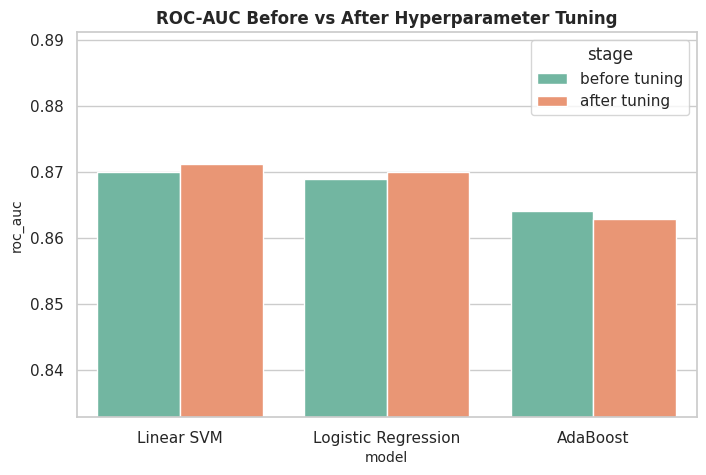

PosixPath('artifacts/figures/50_tuning_before_after.png')

In [42]:
tuned_df = pd.DataFrame([m for m in MODEL_RESULTS if m["tier"] == "tuned"])
before_after = []
for name in top3_names:
    before = all_so_far[all_so_far["model"] == name].iloc[0]
    after = tuned_df[tuned_df["model"] == f"{name} (Tuned)"].iloc[0]
    before_after.append({"model": name, "stage": "before tuning", "roc_auc": before["roc_auc"]})
    before_after.append({"model": name, "stage": "after tuning", "roc_auc": after["roc_auc"]})
before_after_df = pd.DataFrame(before_after)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=before_after_df, x="model", y="roc_auc", hue="stage", palette="Set2", ax=ax)
ax.set_title("ROC-AUC Before vs After Hyperparameter Tuning")
ax.set_ylim(before_after_df["roc_auc"].min() - 0.03, before_after_df["roc_auc"].max() + 0.02)
save_and_show(fig, "tuning_before_after")

Saved CSV artifact -> artifacts/csv/08_top3_cv_score_distributions.csv  (15 rows x 2 cols)


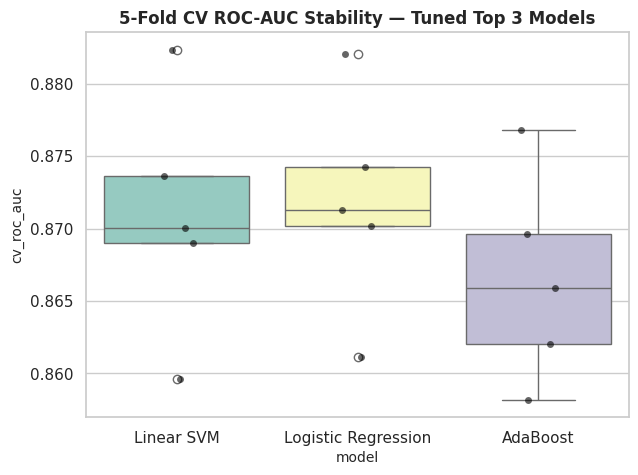

PosixPath('artifacts/figures/51_tuned_cv_score_distribution.png')

In [43]:
cv_score_records = []
for name in top3_names:
    scores = cross_val_score(TUNED_MODELS[name], X_train_t, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    for s in scores:
        cv_score_records.append({"model": name, "cv_roc_auc": s})
cv_score_df = pd.DataFrame(cv_score_records)
save_csv(cv_score_df, "08_top3_cv_score_distributions.csv")

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=cv_score_df, x="model", y="cv_roc_auc", hue="model", palette="Set3", legend=False, ax=ax)
sns.stripplot(data=cv_score_df, x="model", y="cv_roc_auc", color="black", alpha=0.6, size=5, ax=ax)
ax.set_title("5-Fold CV ROC-AUC Stability — Tuned Top 3 Models")
save_and_show(fig, "tuned_cv_score_distribution")

## 11. Model Comparison — All Levels

A consolidated leaderboard spanning baseline, advanced, and tuned tiers, with the full
metric suite and precision-recall curves for the strongest contenders.

In [44]:
results_df = pd.DataFrame(MODEL_RESULTS).sort_values("roc_auc", ascending=False).reset_index(drop=True)
save_csv(results_df, "09_full_model_leaderboard.csv")
results_df

Saved CSV artifact -> artifacts/csv/09_full_model_leaderboard.csv  (14 rows x 8 cols)

,model,tier,accuracy,precision,recall,f1,roc_auc,train_accuracy
0,Linear SVM (Tuned),tuned,0.788571,0.780769,0.690476,0.732852,0.871205,0.789464
1,Logistic Regression (Tuned),tuned,0.785714,0.770677,0.697279,0.732143,0.870053,0.789286
2,Linear SVM,baseline,0.787857,0.775047,0.697279,0.734109,0.869982,0.792321
3,Logistic Regression,baseline,0.785714,0.771698,0.695578,0.731664,0.869018,0.790179
4,AdaBoost,advanced,0.784286,0.767790,0.697279,0.730838,0.864134,0.791429
5,Gradient Boosting,advanced,0.783571,0.771429,0.688776,0.727763,0.863284,0.838393
6,AdaBoost (Tuned),tuned,0.783571,0.775629,0.681973,0.725792,0.862863,0.793750
7,Random Forest,advanced,0.774286,0.773092,0.654762,0.709024,0.857662,0.923214
8,LightGBM,advanced,0.780000,0.756410,0.702381,0.728395,0.856741,0.920714
9,XGBoost,advanced,0.790000,0.772222,0.709184,0.739362,0.854563,0.915536


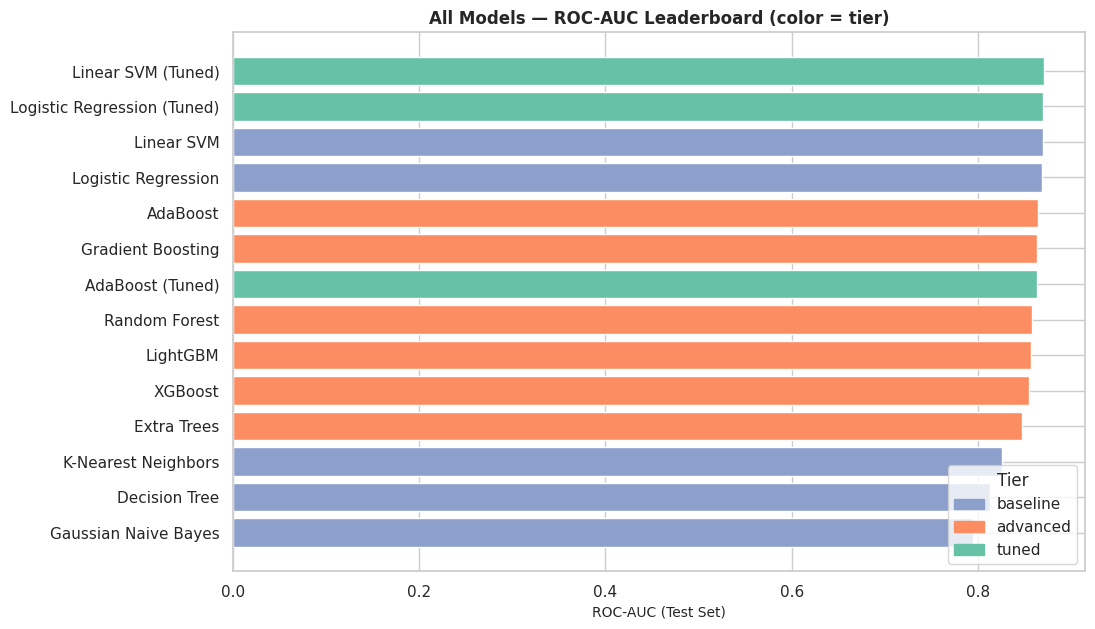

PosixPath('artifacts/figures/52_full_leaderboard_roc_auc.png')

In [45]:
fig, ax = plt.subplots(figsize=(11, 7))
palette_map = {"baseline": "#8DA0CB", "advanced": "#FC8D62", "tuned": "#66C2A5"}
bar_colors = results_df["tier"].map(palette_map)
ax.barh(results_df["model"], results_df["roc_auc"], color=bar_colors)
ax.set_xlabel("ROC-AUC (Test Set)")
ax.set_title("All Models — ROC-AUC Leaderboard (color = tier)")
ax.invert_yaxis()
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette_map.values()]
ax.legend(handles, palette_map.keys(), title="Tier", loc="lower right")
save_and_show(fig, "full_leaderboard_roc_auc")

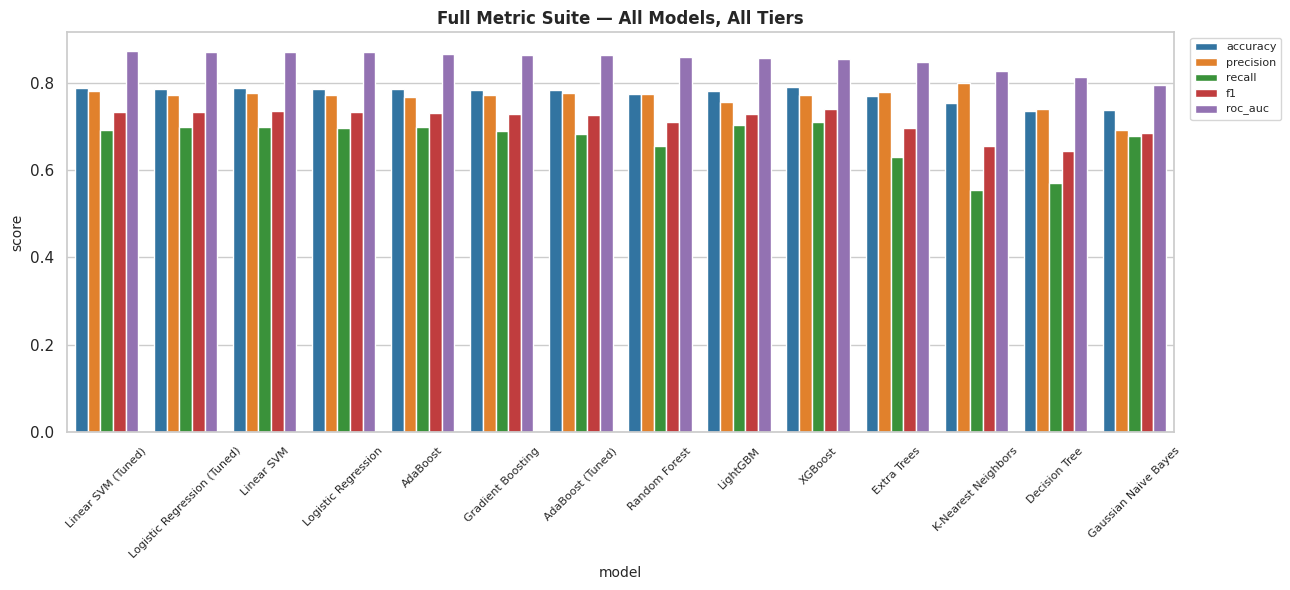

PosixPath('artifacts/figures/53_full_metric_suite_grouped_bar.png')

In [46]:
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
melted = results_df.melt(id_vars=["model", "tier"], value_vars=metric_cols,
                          var_name="metric", value_name="score")
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=melted, x="model", y="score", hue="metric", palette="tab10", ax=ax)
ax.set_title("Full Metric Suite — All Models, All Tiers")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
fig.tight_layout()
save_and_show(fig, "full_metric_suite_grouped_bar")

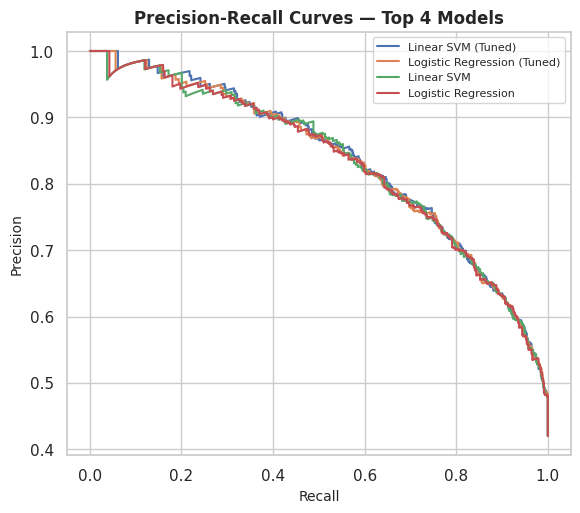

PosixPath('artifacts/figures/54_top4_precision_recall_curves.png')

In [47]:
top4_names = results_df["model"].head(4).tolist()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name in top4_names:
    precision, recall, _ = precision_recall_curve(y_test, MODEL_PROBAS[name])
    ax.plot(recall, precision, label=name)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Top 4 Models")
ax.legend(fontsize=8)
save_and_show(fig, "top4_precision_recall_curves")

In [48]:
BEST_MODEL_NAME = results_df.iloc[0]["model"]
BEST_MODEL = TRAINED_MODELS[BEST_MODEL_NAME]
print(f"Best overall model by test ROC-AUC: {BEST_MODEL_NAME}")
results_df.iloc[0]

Best overall model by test ROC-AUC: Linear SVM (Tuned)


model             Linear SVM (Tuned)
tier                           tuned
accuracy                    0.788571
precision                   0.780769
recall                      0.690476
f1                          0.732852
roc_auc                     0.871205
train_accuracy              0.789464
Name: 0, dtype: object

## 12. Granular Feature Importance

Built-in impurity/gain-based importances for each tuned top-3 model, plus model-agnostic
**permutation importance** (computed on the held-out test fold) for the overall best model —
the gold-standard cross-check against tree-based importance bias toward high-cardinality
features.

Linear SVM has no native feature_importances_; skipping.
Logistic Regression has no native feature_importances_; skipping.


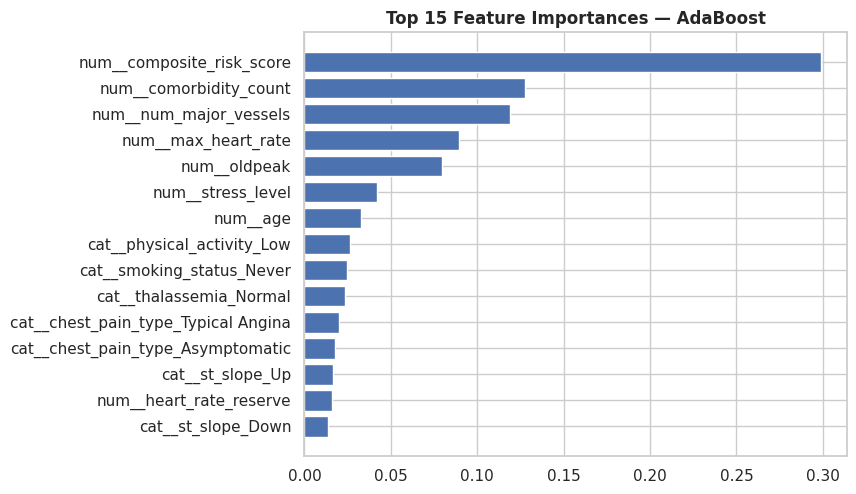

In [49]:
def plot_feature_importance(model, name, feature_names, top_n=15):
    if not hasattr(model, "feature_importances_"):
        print(f"{name} has no native feature_importances_; skipping.")
        return None
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.barh(importances.index[::-1], importances.values[::-1], color="#4C72B0")
    ax.set_title(f"Top {top_n} Feature Importances — {name}")
    save_and_show(fig, f"feat_importance_{name.replace(' ', '_').replace('(', '').replace(')', '')}")
    return importances

importance_records = {}
for name in top3_names:
    model = TUNED_MODELS[name]
    imp = plot_feature_importance(model, name, feature_names_out)
    if imp is not None:
        importance_records[name] = imp

Saved CSV artifact -> artifacts/csv/10_permutation_importance.csv  (54 rows x 3 cols)


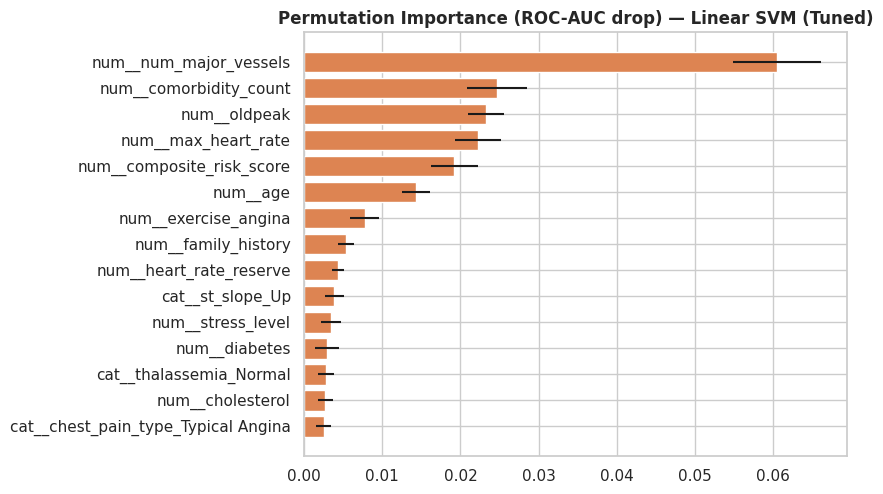

PosixPath('artifacts/figures/56_permutation_importance_best_model.png')

In [50]:
perm_result = permutation_importance(
    BEST_MODEL, X_test_t, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
    scoring="roc_auc"
)
perm_df = pd.DataFrame({
    "feature": feature_names_out,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
save_csv(perm_df, "10_permutation_importance.csv")

top_perm = perm_df.head(15)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(top_perm["feature"][::-1], top_perm["importance_mean"][::-1],
        xerr=top_perm["importance_std"][::-1], color="#DD8452")
ax.set_title(f"Permutation Importance (ROC-AUC drop) — {BEST_MODEL_NAME}")
save_and_show(fig, "permutation_importance_best_model")

## 13. Explainability — SHAP

SHAP (SHapley Additive exPlanations) values attribute each prediction to its input features
in a game-theoretically consistent way. A `TreeExplainer` is used when the best model
supports it (fast, exact); otherwise the notebook falls back to the model-agnostic
`shap.Explainer` on a background sample.

In [51]:
X_train_t_df = pd.DataFrame(X_train_t, columns=feature_names_out)
X_test_t_df = pd.DataFrame(X_test_t, columns=feature_names_out)

background = shap.sample(X_train_t_df, 40, random_state=RANDOM_STATE)
shap_sample = X_test_t_df.sample(n=min(60, len(X_test_t_df)), random_state=RANDOM_STATE)

try:
    shap_explainer = shap.TreeExplainer(BEST_MODEL)
    shap_values = shap_explainer(shap_sample)
except Exception as e_tree:
    if hasattr(BEST_MODEL, "coef_"):
        print("Model exposes linear coefficients -> using fast shap.LinearExplainer.")
        shap_explainer = shap.LinearExplainer(BEST_MODEL, background)
        shap_values = shap_explainer(shap_sample)
    else:
        print("TreeExplainer/LinearExplainer unavailable for this model type, "
              "using bounded model-agnostic Explainer:", e_tree)
        shap_explainer = shap.Explainer(BEST_MODEL.predict_proba, background)
        shap_values = shap_explainer(shap_sample, max_evals=200)

if len(shap_values.shape) == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values

print("SHAP values computed for", shap_sample.shape[0], "test samples across", shap_sample.shape[1], "features.")

Model exposes linear coefficients -> using fast shap.LinearExplainer.
SHAP values computed for 60 test samples across 54 features.


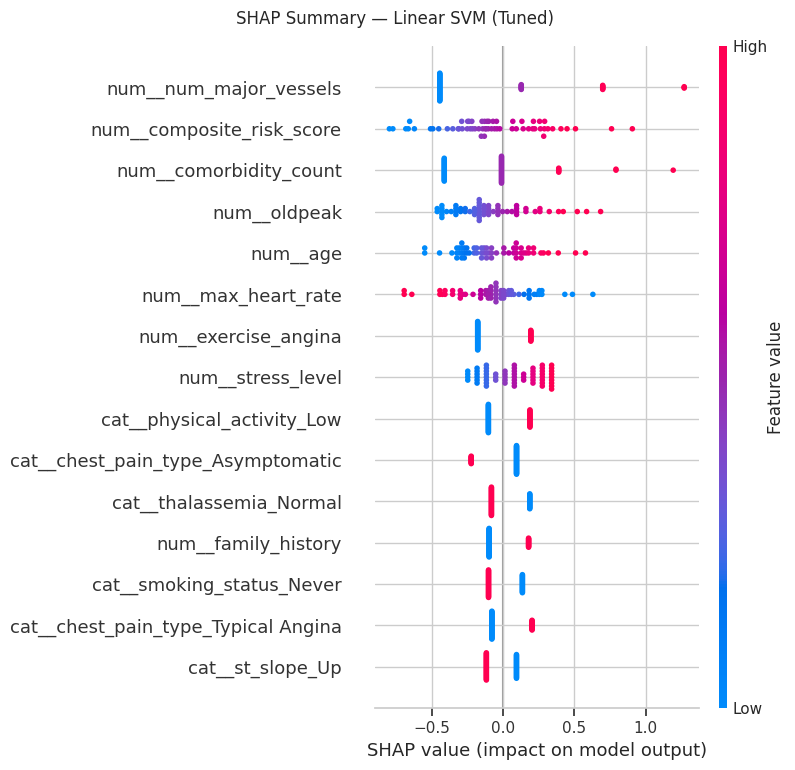

PosixPath('artifacts/figures/57_shap_summary_beeswarm.png')

In [52]:
shap.summary_plot(shap_values_plot, shap_sample, show=False, max_display=15)
fig = plt.gcf()
fig.suptitle(f"SHAP Summary — {BEST_MODEL_NAME}", y=1.02)
save_and_show(fig, "shap_summary_beeswarm")

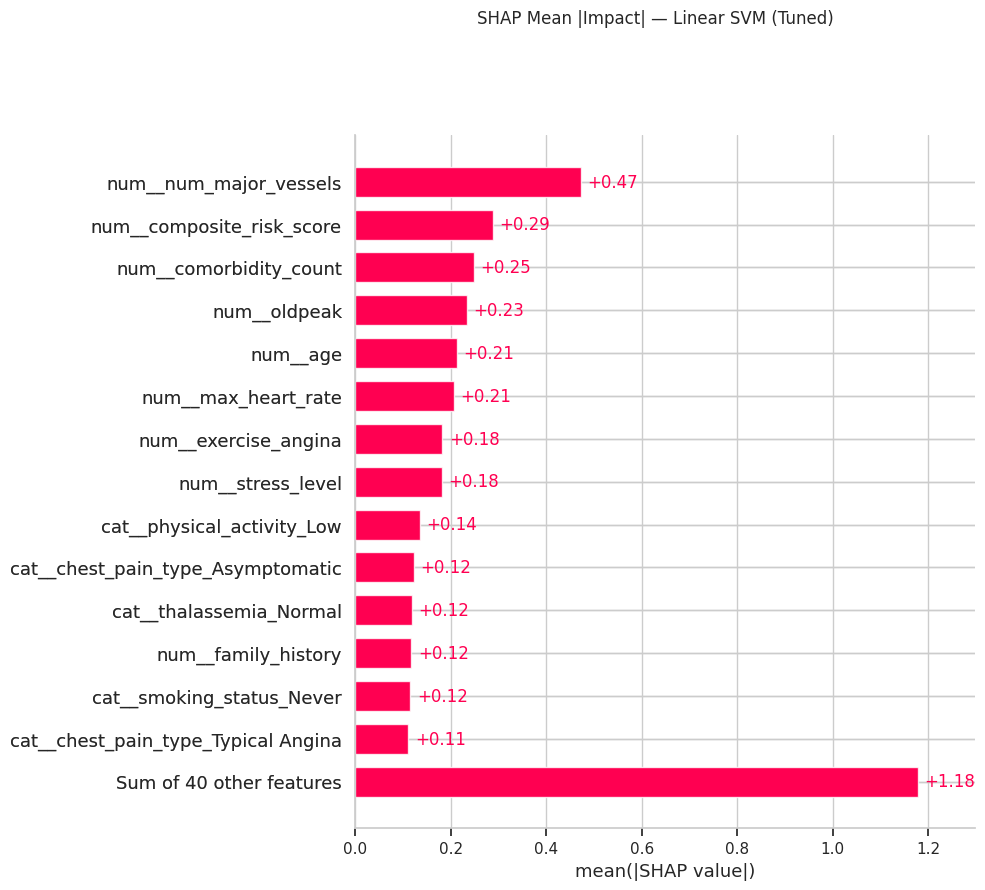

PosixPath('artifacts/figures/58_shap_bar_mean_impact.png')

In [53]:
shap.plots.bar(shap_values_plot, show=False, max_display=15)
fig = plt.gcf()
fig.suptitle(f"SHAP Mean |Impact| — {BEST_MODEL_NAME}", y=1.02)
save_and_show(fig, "shap_bar_mean_impact")

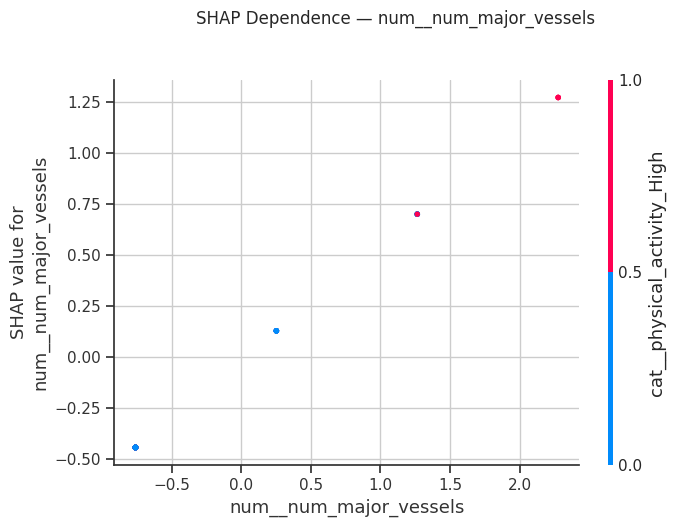

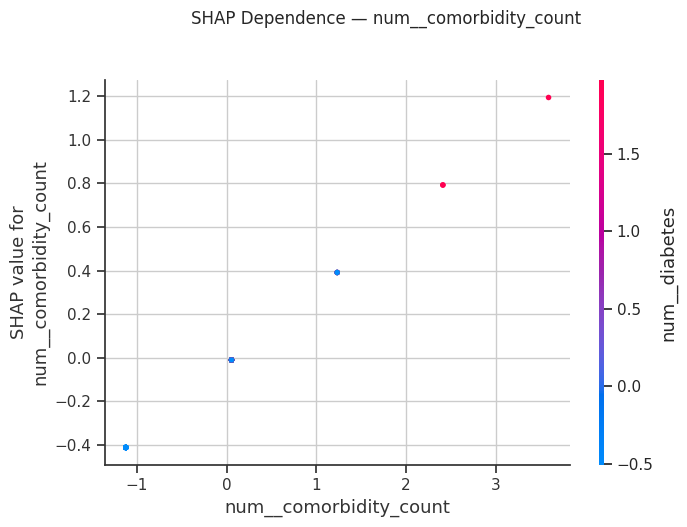

In [54]:
top2_shap_features = perm_df["feature"].head(2).tolist()
for feat in top2_shap_features:
    shap.dependence_plot(feat, shap_values_plot.values, shap_sample, show=False)
    fig = plt.gcf()
    fig.suptitle(f"SHAP Dependence — {feat}", y=1.02)
    save_and_show(fig, f"shap_dependence_{feat}")

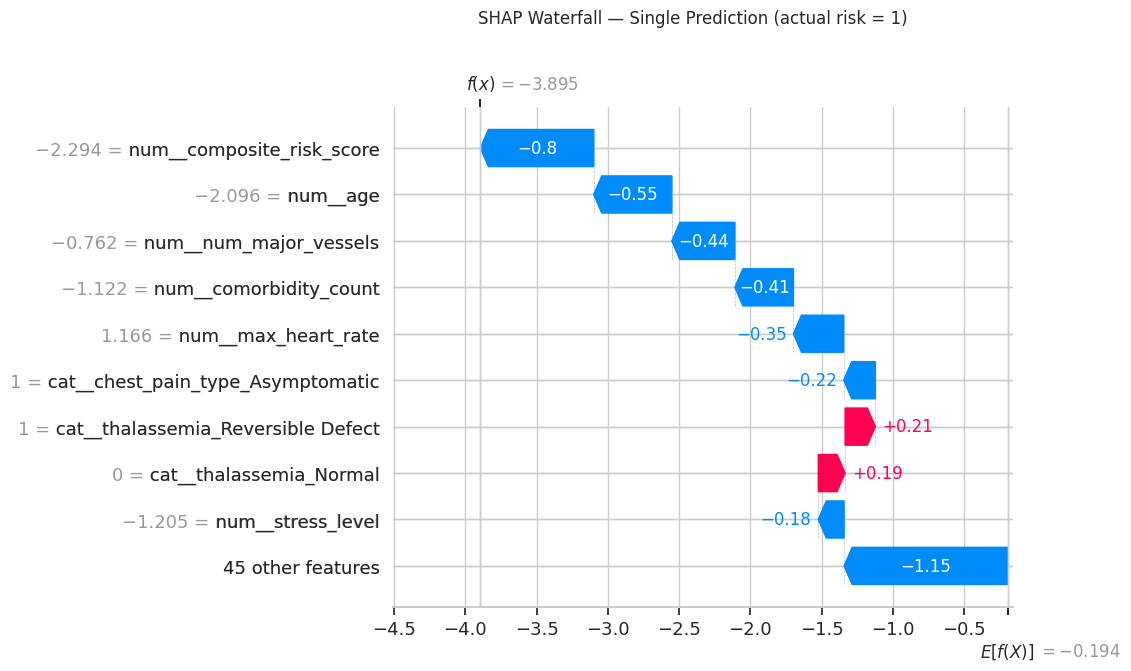

PosixPath('artifacts/figures/61_shap_waterfall_single_prediction.png')

In [55]:
sample_idx = 0
shap.plots.waterfall(shap_values_plot[sample_idx], show=False)
fig = plt.gcf()
actual = y_test.iloc[sample_idx] if hasattr(y_test, "iloc") else y_test[sample_idx]
fig.suptitle(f"SHAP Waterfall — Single Prediction (actual risk = {actual})", y=1.03)
save_and_show(fig, "shap_waterfall_single_prediction")

## 14. Explainability — LIME

LIME (Local Interpretable Model-agnostic Explanations) perturbs a single instance's features
and fits a local surrogate linear model to explain that one prediction — complementary to
SHAP's global-consistency view. Two contrasting cases are explained: a correctly predicted
high-risk patient and a correctly predicted low-risk patient.

In [56]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_t,
    feature_names=list(feature_names_out),
    class_names=["Low Risk", "High Risk"],
    mode="classification",
    random_state=RANDOM_STATE,
)

y_test_arr = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)
best_model_preds = BEST_MODEL.predict(X_test_t)

high_risk_idx = np.where((y_test_arr == 1) & (best_model_preds == 1))[0][0]
low_risk_idx = np.where((y_test_arr == 0) & (best_model_preds == 0))[0][0]
print("Explaining a correctly-classified HIGH-risk case (index", high_risk_idx, ") and a "
      "correctly-classified LOW-risk case (index", low_risk_idx, ")")

Explaining a correctly-classified HIGH-risk case (index 0 ) and a correctly-classified LOW-risk case (index 2 )


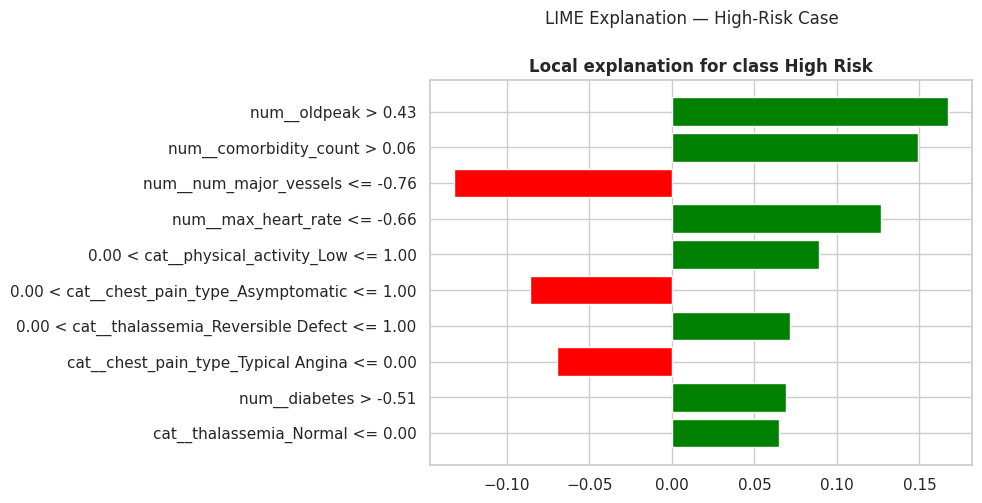

PosixPath('artifacts/figures/62_lime_high_risk_case.png')

In [57]:
exp_high = lime_explainer.explain_instance(
    X_test_t[high_risk_idx], BEST_MODEL.predict_proba, num_features=10, num_samples=2000
)
fig = exp_high.as_pyplot_figure()
fig.set_size_inches(7, 5)
fig.suptitle("LIME Explanation — High-Risk Case", y=1.02)
save_and_show(fig, "lime_high_risk_case")

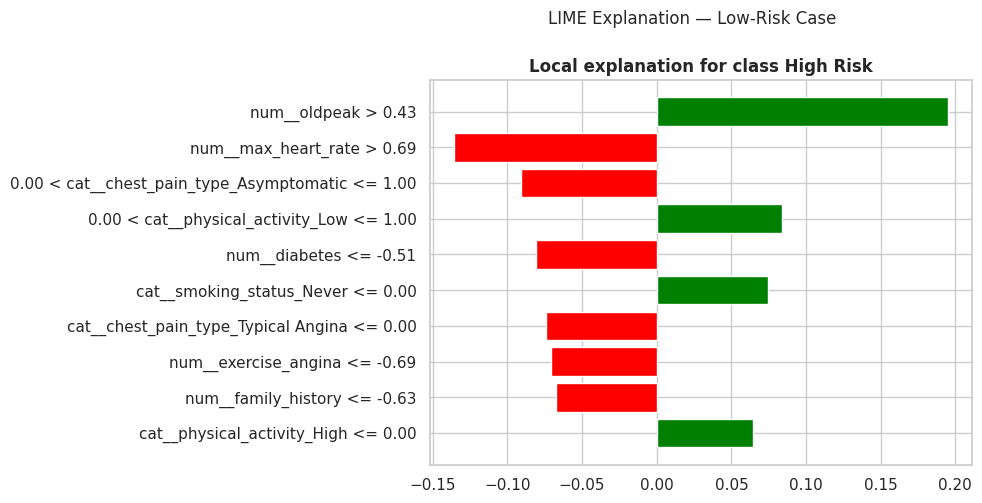

PosixPath('artifacts/figures/63_lime_low_risk_case.png')

In [58]:
exp_low = lime_explainer.explain_instance(
    X_test_t[low_risk_idx], BEST_MODEL.predict_proba, num_features=10, num_samples=2000
)
fig = exp_low.as_pyplot_figure()
fig.set_size_inches(7, 5)
fig.suptitle("LIME Explanation — Low-Risk Case", y=1.02)
save_and_show(fig, "lime_low_risk_case")

## 15. Bias-Variance Trade-off & Overfitting Diagnostics

- **Learning curves** for the tuned top-3 models show how train vs cross-validated score
  converge (or don't) as training-set size grows — a shrinking gap signals healthy variance;
  a persistent gap signals overfitting; low scores on both signals underfitting (high bias).
- **Train-vs-test accuracy gap** across every model in the leaderboard is a quick overfitting
  scan.
- A **validation curve** on the best model's key complexity hyperparameter visualizes the
  classic bias-variance U-shape.

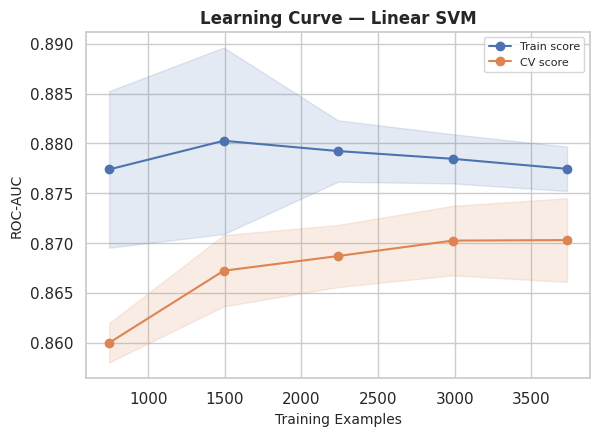

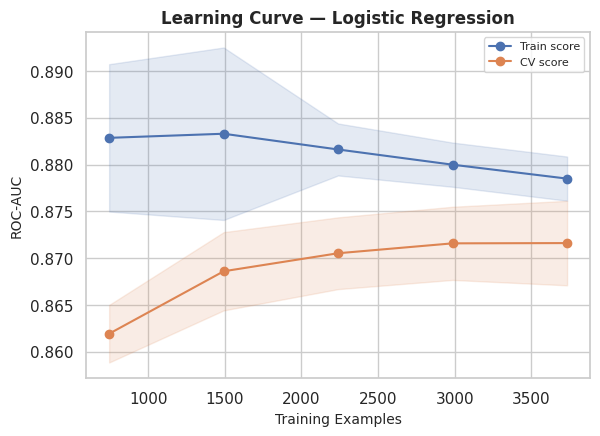

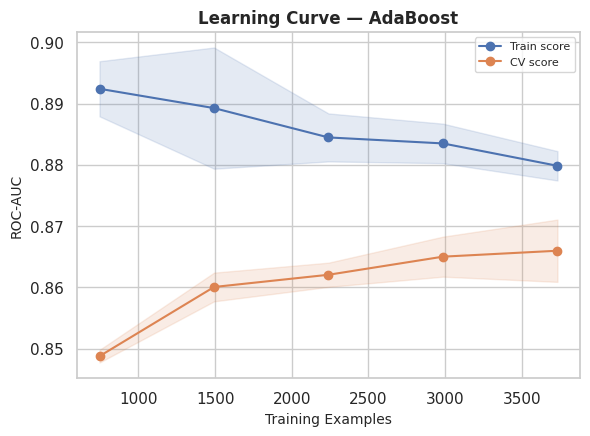

In [59]:
def plot_learning_curve(model, name, X_tr, y_tr):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_tr, y_tr, cv=tuning_cv, scoring="roc_auc",
        train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1, random_state=RANDOM_STATE
    )
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train score", color="#4C72B0")
    ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="#4C72B0")
    ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="CV score", color="#DD8452")
    ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#DD8452")
    ax.set_xlabel("Training Examples")
    ax.set_ylabel("ROC-AUC")
    ax.set_title(f"Learning Curve — {name}")
    ax.legend(fontsize=8)
    save_and_show(fig, f"learning_curve_{name.replace(' ', '_')}")

for name in top3_names:
    lc_estimator = clone(TUNED_MODELS[name])
    if isinstance(lc_estimator, SVC):
        lc_estimator.set_params(probability=False)
    plot_learning_curve(lc_estimator, name, X_train_t, y_train)

Saved CSV artifact -> artifacts/csv/11_overfitting_gap_scan.csv  (14 rows x 5 cols)


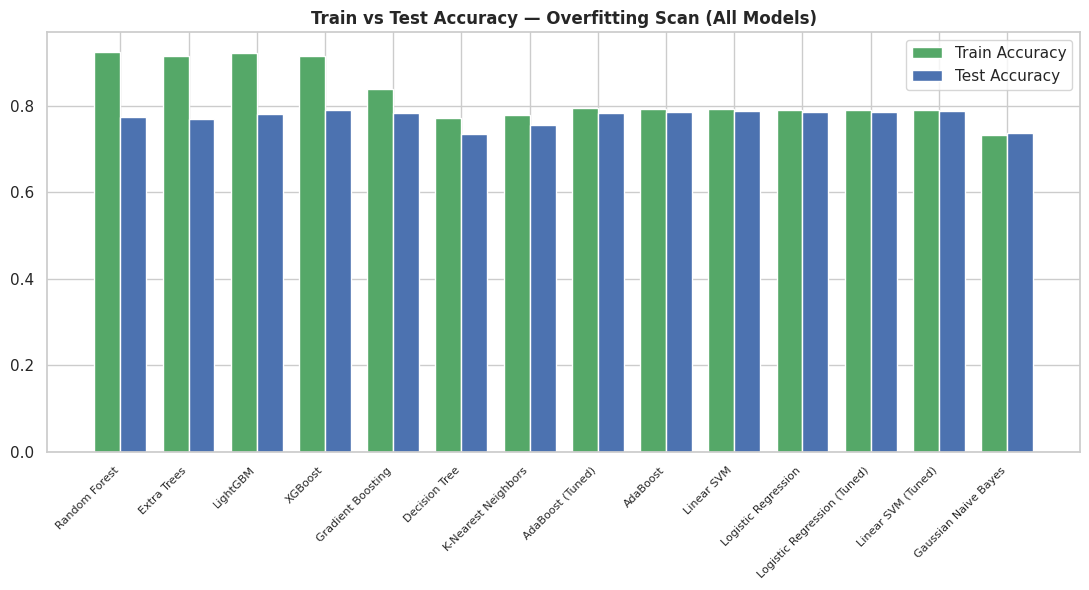

PosixPath('artifacts/figures/67_overfitting_train_test_gap.png')

In [60]:
gap_df = results_df.copy()
gap_df["overfit_gap"] = gap_df["train_accuracy"] - gap_df["accuracy"]
gap_df = gap_df.sort_values("overfit_gap", ascending=False)
save_csv(gap_df[["model", "tier", "train_accuracy", "accuracy", "overfit_gap"]], "11_overfitting_gap_scan.csv")

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(gap_df))
width = 0.38
ax.bar(x - width/2, gap_df["train_accuracy"], width, label="Train Accuracy", color="#55A868")
ax.bar(x + width/2, gap_df["accuracy"], width, label="Test Accuracy", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(gap_df["model"], rotation=45, ha="right", fontsize=8)
ax.set_title("Train vs Test Accuracy — Overfitting Scan (All Models)")
ax.legend()
fig.tight_layout()
save_and_show(fig, "overfitting_train_test_gap")

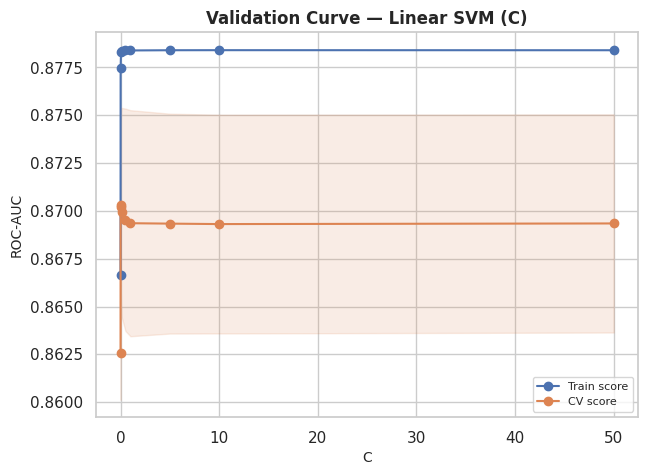

In [61]:
vc_param_grid = {
    "Random Forest": ("max_depth", [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]),
    "Extra Trees": ("max_depth", [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]),
    "XGBoost": ("max_depth", [1, 2, 3, 4, 5, 6, 8, 10]),
    "LightGBM": ("max_depth", [1, 2, 3, 4, 5, 6, 8, 10]),
    "Gradient Boosting": ("max_depth", [1, 2, 3, 4, 5, 6, 8]),
    "AdaBoost": ("n_estimators", [10, 25, 50, 100, 150, 200, 300, 400]),
    "Decision Tree": ("max_depth", [1, 2, 3, 4, 5, 6, 8, 10, 12, 15]),
    "Logistic Regression": ("C", [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]),
    "K-Nearest Neighbors": ("n_neighbors", [1, 3, 5, 8, 12, 16, 20, 25, 30, 40]),
    "Linear SVM": ("C", [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]),
}

base_name_for_vc = BEST_MODEL_NAME.replace(" (Tuned)", "")
if base_name_for_vc in vc_param_grid:
    param_name, param_range = vc_param_grid[base_name_for_vc]
    vc_estimator = clone(ALL_MODEL_INSTANCES.get(base_name_for_vc, BEST_MODEL))
    if isinstance(vc_estimator, SVC):
        vc_estimator.set_params(probability=False)
    train_scores, val_scores = validation_curve(
        vc_estimator, X_train_t, y_train, param_name=param_name, param_range=param_range,
        cv=tuning_cv, scoring="roc_auc", n_jobs=-1
    )
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(param_range, train_scores.mean(axis=1), "o-", label="Train score", color="#4C72B0")
    ax.plot(param_range, val_scores.mean(axis=1), "o-", label="CV score", color="#DD8452")
    ax.fill_between(param_range, val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#DD8452")
    ax.set_xlabel(param_name)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(f"Validation Curve — {base_name_for_vc} ({param_name})")
    ax.legend(fontsize=8)
    save_and_show(fig, f"validation_curve_{base_name_for_vc.replace(' ', '_')}")
else:
    print(f"No validation-curve hyperparameter mapped for {base_name_for_vc}; skipping.")

## 16. Final Model Selection, Artifact Export & Download

Final diagnostics for the champion model, a consolidated predictions export, and packaging
of every figure/CSV artifact generated in this notebook into a single downloadable ZIP.

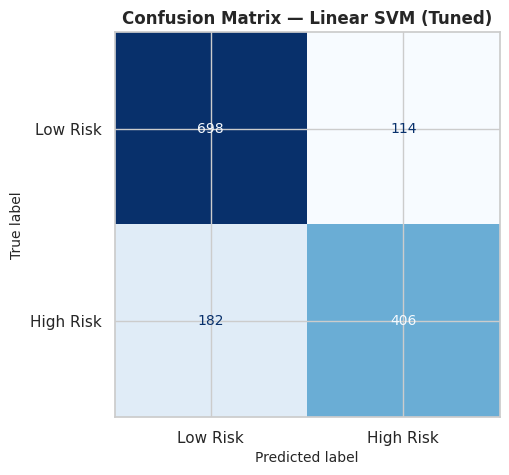

PosixPath('artifacts/figures/69_final_confusion_matrix.png')

In [62]:
y_pred_final = BEST_MODEL.predict(X_test_t)
y_proba_final = MODEL_PROBAS[BEST_MODEL_NAME]

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"Confusion Matrix — {BEST_MODEL_NAME}")
save_and_show(fig, "final_confusion_matrix")

Saved CSV artifact -> artifacts/csv/12_final_classification_report.csv  (5 rows x 5 cols)


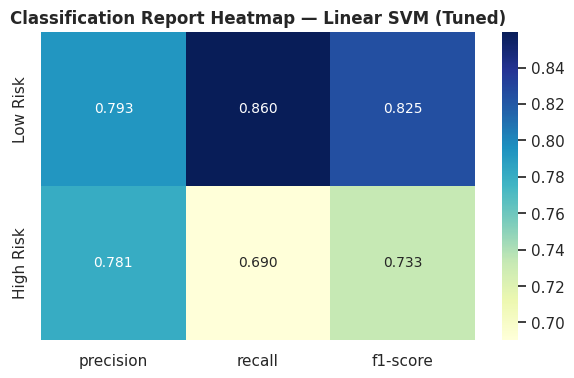

PosixPath('artifacts/figures/70_final_classification_report_heatmap.png')

In [63]:
report_dict = classification_report(y_test, y_pred_final, target_names=["Low Risk", "High Risk"], output_dict=True)
report_df = pd.DataFrame(report_dict).T
save_csv(report_df.reset_index().rename(columns={"index": "class"}), "12_final_classification_report.csv")

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(report_df.iloc[:-3, :-1].astype(float), annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title(f"Classification Report Heatmap — {BEST_MODEL_NAME}")
save_and_show(fig, "final_classification_report_heatmap")

In [64]:
predictions_export = X_test.copy()
predictions_export["actual_risk"] = y_test.values
predictions_export["predicted_risk"] = y_pred_final
predictions_export["predicted_probability"] = y_proba_final
save_csv(predictions_export, "13_final_test_set_predictions.csv")
predictions_export.head()

Saved CSV artifact -> artifacts/csv/13_final_test_set_predictions.csv  (1400 rows x 30 cols)


,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,...,age_group,bp_category,cholesterol_category,bmi_category,heart_rate_reserve,composite_risk_score,comorbidity_count,actual_risk,predicted_risk,predicted_probability
2064,56,Male,Asymptomatic,118.0,180.0,0.0,ST-T Abnormality,148.0,0,2.6,...,senior,normal,desirable,normal,16.0,-0.025556,3.0,1,1,0.931034
6101,55,Female,Non-anginal Pain,NaN,204.0,0.0,ST-T Abnormality,NaN,0,0.7,...,senior,NaN,borderline_high,normal,NaN,0.132667,1.0,1,0,0.416322
1064,47,Female,Asymptomatic,120.0,210.0,1.0,Left Ventricular Hypertrophy,209.0,0,1.8,...,middle_aged,normal,borderline_high,obese,-36.0,0.451667,1.0,0,0,0.456939
814,66,Male,Non-anginal Pain,108.0,106.0,0.0,Normal,150.0,1,2.9,...,elderly,normal,desirable,underweight,4.0,-0.115556,0.0,1,0,0.316356
5934,75,Female,Non-anginal Pain,124.0,229.0,1.0,Normal,142.0,1,0.8,...,elderly,elevated,borderline_high,obese,3.0,0.943056,3.0,1,1,0.997185


In [65]:
print("=" * 70)
print(f"FINAL MODEL      : {BEST_MODEL_NAME}")
print(f"Test Accuracy     : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Test Precision    : {precision_score(y_test, y_pred_final):.4f}")
print(f"Test Recall       : {recall_score(y_test, y_pred_final):.4f}")
print(f"Test F1-score     : {f1_score(y_test, y_pred_final):.4f}")
print(f"Test ROC-AUC      : {roc_auc_score(y_test, y_proba_final):.4f}")
print("=" * 70)
print(f"\nTotal inline visuals generated in this notebook: {_VIS_COUNTER['n']}")

FINAL MODEL      : Linear SVM (Tuned)
Test Accuracy     : 0.7886
Test Precision    : 0.7808
Test Recall       : 0.6905
Test F1-score     : 0.7329
Test ROC-AUC      : 0.8712

Total inline visuals generated in this notebook: 70


In [66]:
import joblib

final_pipeline = Pipeline(steps=[
    ("features", ClinicalFeatureBuilder()),
    ("preprocess", preprocessor),
    ("model", BEST_MODEL),
])
joblib.dump(final_pipeline, MODEL_DIR / "final_pipeline.joblib")
print("Saved full inference pipeline (feature engineering + preprocessing + model) ->",
      MODEL_DIR / "final_pipeline.joblib")

Saved full inference pipeline (feature engineering + preprocessing + model) -> artifacts/models/final_pipeline.joblib


In [67]:
zip_path = Path("heart_attack_risk_project_artifacts.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in (FIG_DIR, CSV_DIR, MODEL_DIR):
        for file in folder.rglob("*"):
            if file.is_file():
                zf.write(file, arcname=file.relative_to(ARTIFACT_DIR.parent))

size_mb = zip_path.stat().st_size / (1024 * 1024)
print(f"Artifact archive created: {zip_path}  ({size_mb:.2f} MB)")
print(f"Contains {len(list(FIG_DIR.glob('*.png')))} figures, "
      f"{len(list(CSV_DIR.glob('*.csv')))} CSV files, "
      f"{len(list(MODEL_DIR.glob('*')))} model file(s).")

Artifact archive created: heart_attack_risk_project_artifacts.zip  (4.10 MB)
Contains 70 figures, 13 CSV files, 1 model file(s).


In [68]:
if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))
    print("Download triggered in Colab.")
else:
    print(f"Not running in Colab — artifact archive is available locally at: {zip_path.resolve()}")

Not running in Colab — artifact archive is available locally at: /home/claude/nb_build/heart_attack_risk_project_artifacts.zip


### Summary

This notebook progressed from raw, imperfect clinical-style data through rigorous statistical
validation, leak-free feature engineering, a three-tier model benchmark (baseline → advanced →
tuned), dual explainability lenses (SHAP + LIME), and explicit bias-variance / overfitting
diagnostics — producing a fully reproducible, artifact-backed project suitable for a written
report or portfolio submission.

**Reminder:** synthetic dataset — for ML practice only, not for clinical use.